<a href="https://colab.research.google.com/github/rinermdhn/Customer-Classification-for-Marketing-Campaigns-in-Term-Deposit-Subscription/blob/main/Customer_Classification_for_Marketing_Campaigns_in_Term_Deposit_Subscription.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Pendahuluan

####**Latar Belakang**
Dalam dunia perbankan, strategi pemasaran yang efektif sangat penting untuk menarik perhatian pelanggan dan mendorong mereka untuk menggunakan produk keuangan tertentu. Salah satu tantangan utama yang dihadapi oleh bank adalah menentukan faktor-faktor yang memengaruhi keputusan pelanggan untuk berlangganan produk deposito berjangka (*term deposit*).
Analisis terhadap data kampanye pemasaran langsung yang dilakukan oleh bank dapat memberikan wawasan berharga mengenai karakteristik pelanggan yang cenderung berlangganan produk ini.
Dataset yang digunakan dalam analisis ini adalah Bank Marketing Dataset yang berasal dari kampanye pemasaran langsung oleh sebuah institusi perbankan Portugis. Dataset yang akan digunakan berasal dari UCI Machine Learning Repository. Data ini mencakup informasi demografis pelanggan, interaksi selama kampanye, serta faktor ekonomi makro yang relevan.

####**Ukuran dan Karakteristik Data**
Dataset ini memiliki jumlah baris sebanyak 45.211 dan 20 variabel dengan 1 variabel target, yaitu Apakah pelanggan berlangganan deposito berjangka ("yes" atau "no"). Tipe data pada dataset ini merupakan variabel numerik dan kategorik dengan skala pengukuran data bersifat campuran antara ordinal, nominal, dan rasio. Dataset ini menyediakan informasi yang cukup untuk memahami hubungan antara atribut pelanggan dengan keputusan mereka, sehingga analisis lebih lanjut dapat membantu meningkatkan strategi pemasaran bank.

####**Tujuan Analisis**
Tujuan dari analisis kami, yaitu memberikan rekomendasi strategis kepada bank mengenai segmen pelanggan yang harus menjadi prioritas dalam kampanye pemasaran dan wawasan tentang faktor-faktor yang perlu ditingkatkan dalam proses pemasaran untuk meningkatkan tingkat subscription produk deposito berjangka.

1. Eksplorasi Data:
    * Mengeksplorasi dataset Bank Marketing untuk memahami karakteristik dan pola dari data yang tersedia.
    * Menganalisis faktor-faktor demografis (seperti usia, pekerjaan, tingkat pendidikan) dan faktor interaksi yang berhubungan dengan kemungkinan pelanggan berlangganan produk deposito berjangka.
    * Mengidentifikasi distribusi variabel target (subscribe: "yes" atau "no") serta hubungan antar variabel lainnya.
2. Analisis Klasifikasi:
    * Menggunakan metode klasifikasi untuk memprediksi kemungkinan seorang pelanggan akan berlangganan produk deposito berjangka berdasarkan atribut pelanggan dan hasil kampanye.
    * Menentukan faktor-faktor yang paling signifikan dalam memengaruhi keputusan pelanggan.
    * Mengevaluasi performa model klasifikasi yang digunakan (Logistic Regression, Random Forest, dan decision Tree).


In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 364.4/364.4 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.5/233.5 kB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.6/78.6 kB 6.5 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import missingno as msno

import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder , StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, f1_score, roc_auc_score, precision_score, recall_score, make_scorer, accuracy_score
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

from imblearn.over_sampling import SMOTE , RandomOverSampler
import optuna
import shap

import warnings

from tqdm import tqdm

warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', 1000)
sns.set(style='darkgrid')

# Import Data

In [ ]:
data = pd.read_csv('https://raw.githubusercontent.com/zzeiidann/Data/refs/heads/main/bank-additional-full.csv', sep=';')

train, test = train_test_split(data, test_size=0.2, random_state=42, stratify=data['y'])
train = train.reset_index(drop=True)
test = test.reset_index(drop=True)

## Preprocessing

In [ ]:
def gain_info(data):
    print('\nData Information:')
    print(data.info())

def describe_data(data):
    print('\nData Description:')
    print(data.describe())

def missing_values(data):
    print('\nTotal Missing Values:' , data.isnull().sum().sum())
    print('\nMissing Values:')
    print(data.isnull().sum())

def duplicate_values(data):
    print('\nTotal Duplicate Values:', data.duplicated().sum())

### Train

In [ ]:
gain_info(train)


Data Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32950 entries, 0 to 32949
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             32950 non-null  int64  
 1   job             32950 non-null  object 
 2   marital         32950 non-null  object 
 3   education       32950 non-null  object 
 4   default         32950 non-null  object 
 5   housing         32950 non-null  object 
 6   loan            32950 non-null  object 
 7   contact         32950 non-null  object 
 8   month           32950 non-null  object 
 9   day_of_week     32950 non-null  object 
 10  duration        32950 non-null  int64  
 11  campaign        32950 non-null  int64  
 12  pdays           32950 non-null  int64  
 13  previous        32950 non-null  int64  
 14  poutcome        32950 non-null  object 
 15  emp.var.rate    32950 non-null  float64
 16  cons.price.idx  32950 non-null  float64
 17  cons.conf.id

In [ ]:
missing_values(train)


Total Missing Values: 0

Missing Values:
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64


In [ ]:
duplicate_values(train)


Total Duplicate Values: 8


In [ ]:
train.drop_duplicates(inplace=True)

In [ ]:
train.head(5)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,49,blue-collar,married,basic.9y,unknown,no,no,cellular,nov,wed,...,4,999,0,nonexistent,-0.1,93.200,-42.0,4.120,5195.8,no
1,37,entrepreneur,married,university.degree,no,no,no,telephone,nov,wed,...,2,999,1,failure,-0.1,93.200,-42.0,4.120,5195.8,no
2,78,retired,married,basic.4y,no,no,no,cellular,jul,mon,...,1,999,0,nonexistent,-1.7,94.215,-40.3,0.870,4991.6,yes
3,36,admin.,married,university.degree,no,yes,no,telephone,may,mon,...,2,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,59,retired,divorced,university.degree,no,no,no,cellular,jun,tue,...,2,999,0,nonexistent,-2.9,92.963,-40.8,1.262,5076.2,no


Sedikit Curious di bagian `Default` , `Housing`, `Loan`. Pada deksripsi data yang ada di **UCI MACHINE LEARNING** dijelaskan tidak ada nilai *unknown*
| Column  | Description |
|---------|-------------|
| `default` | has credit in default? (binary: "yes","no") |
| `housing` | has housing loan? (binary: "yes","no") |
| `loan`    | has personal loan? (binary: "yes","no") |



In [ ]:
for col in train[['default', 'housing', 'loan']].columns:
    print('\nUnique Values in', col)
    print(train[col].unique())


Unique Values in default
['unknown' 'no' 'yes']

Unique Values in housing
['no' 'yes' 'unknown']

Unique Values in loan
['no' 'yes' 'unknown']


dapat disimpulkan bahwa nilai `Unknown` ini adalah ***Missing Values*** , selanjutnya kami akan melihat hal apa yang harus dilakukan terkait masalah tersebut
apakah harus *diimputasi*? atau harus *didrop* saja.

In [ ]:
for col in train[['default', 'housing', 'loan']].columns:
    print('\nUnique Values Proportion in', col)
    print(train[col].value_counts(normalize=True))


Unique Values Proportion in default
default
no         0.789266
unknown    0.210643
yes        0.000091
Name: proportion, dtype: float64

Unique Values Proportion in housing
housing
yes        0.523678
no         0.452158
unknown    0.024164
Name: proportion, dtype: float64

Unique Values Proportion in loan
loan
no         0.823356
yes        0.152480
unknown    0.024164
Name: proportion, dtype: float64


Lets Visualize it!

<Axes: >

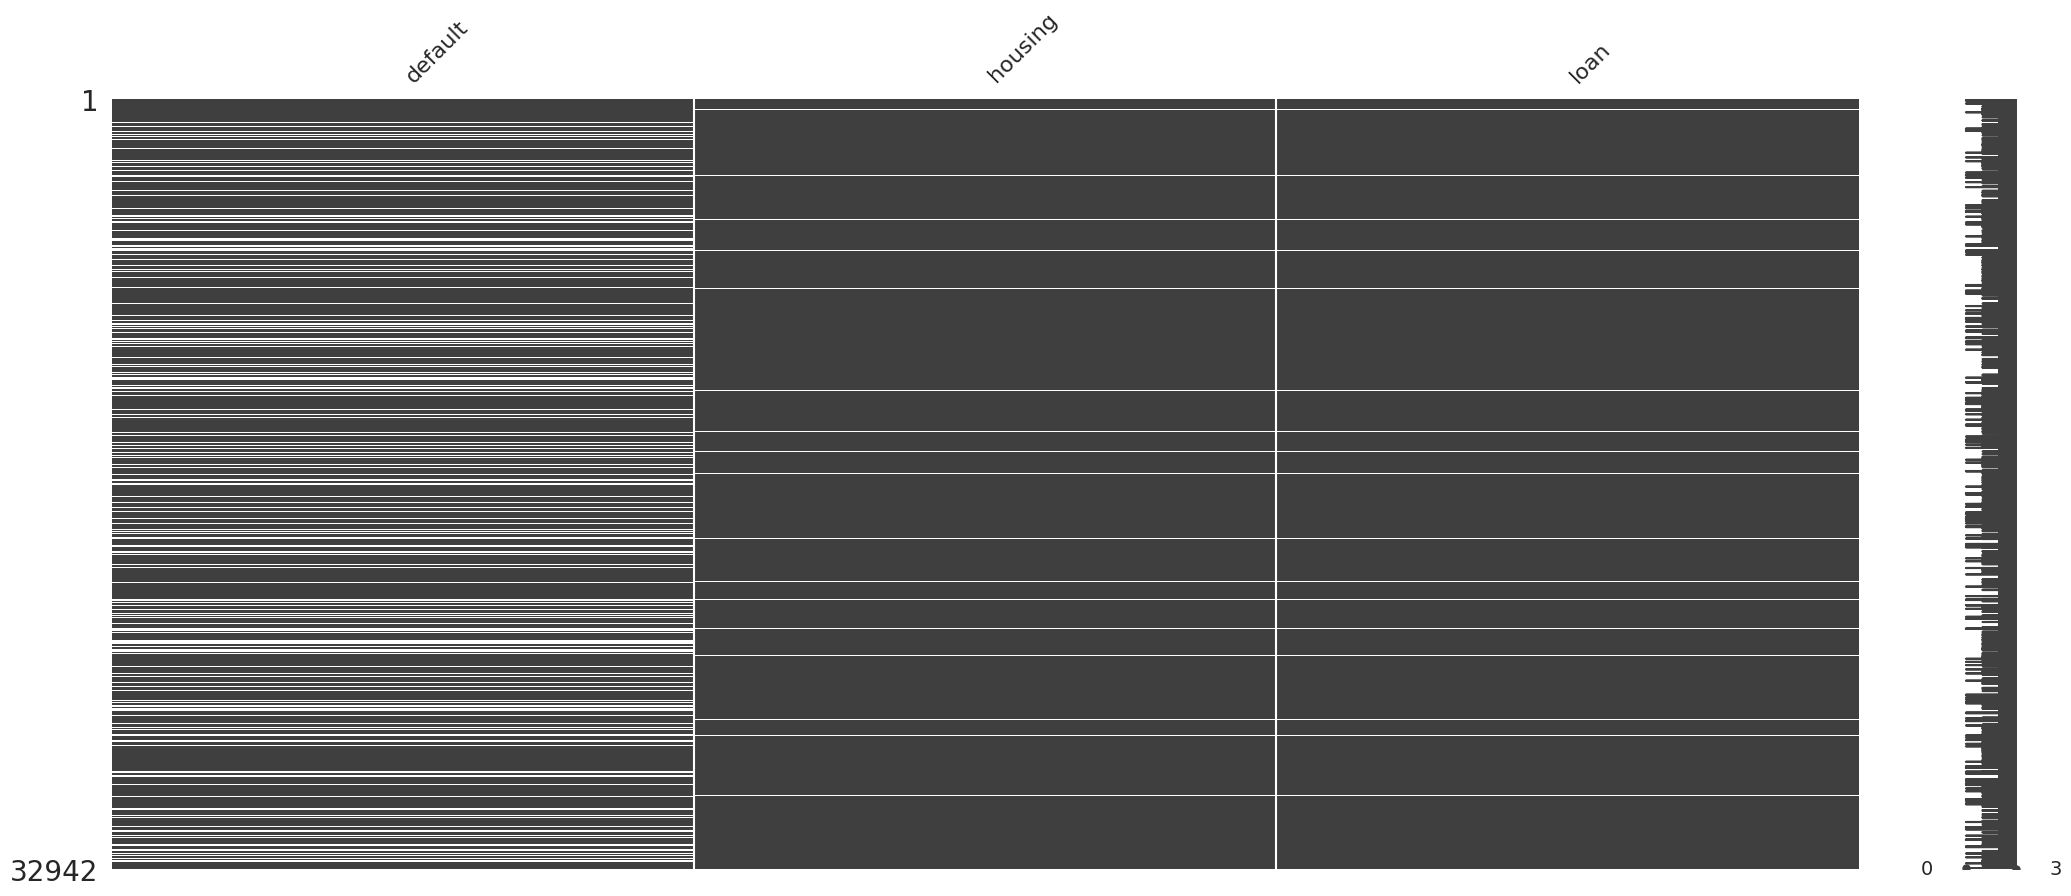

In [ ]:
df_plot1 = train[['default', 'housing', 'loan']]
df_plot1 = df_plot1.replace('unknown', np.nan)

msno.matrix(df_plot1)

Baik dari gambar, keputusan kami adalah menghapus missing value yang ada di `Housing` dan `Loan` dan mengimputasi value yang ada di `Default`.

Hal ini didasari oleh jumlah proporsi nilai hilang yang ada di kolom `Default` sangatlah banyak sekitar 20% , sedangkan kolom `Housing` dan `Loan` tidak sampai 1% dari data.

Karena kolom `default` adalah kolom kategorik , maka kami akan mengimputasinya dengan `mode` (modus). Oleh karena itu nilai yang hilang akan diisi oleh nilai `No` karena nilai `No` adalah nilai yang paling sering muncul berdasrkan:

| Unique Values |Proportion in default |
|------------|------------------------|
| no         | 0.789266               |
| unknown    | 0.210643               |
| yes        | 0.000091               |



In [ ]:
col_to_process = ['default', 'housing', 'loan']

for col in col_to_process:
    if col == 'default':
        train[col].replace('unknown', 'no', inplace=True)
        print('\nUnique Values Proportion in', col)
        print(train[col].value_counts(normalize=True))
    else:
        train[col].replace('unknown', np.nan, inplace=True)
        train = train[train[col].notna()]
        print('\nUnique Values Proportion in', col)
        print(train[col].value_counts(normalize=True))


Unique Values Proportion in default
default
no     0.999909
yes    0.000091
Name: proportion, dtype: float64

Unique Values Proportion in housing
housing
yes    0.536645
no     0.463355
Name: proportion, dtype: float64

Unique Values Proportion in loan
loan
no     0.843744
yes    0.156256
Name: proportion, dtype: float64


Selanjutnya kita akan melihat kesuluruhan kolom kembali agar tidak ada missing information dari deskripsi data yang diberikan.

| Column          | Description                                                                 |
|-----------------|-----------------------------------------------------------------------------|
| age             | (numeric)                                                                   |
| job             | type of job (categorical: "admin.","unknown","unemployed","management","housemaid","entrepreneur","student","blue-collar","self-employed","retired","technician","services") |
| marital         | marital status (categorical: "married","divorced","single"; note: "divorced" means divorced or widowed) |
| education       | (categorical: "unknown","secondary","primary","tertiary")                   |
| default         | has credit in default? (binary: "yes","no")                                 |
| balance         | average yearly balance, in euros (numeric)                                  |
| housing         | has housing loan? (binary: "yes","no")                                      |
| loan            | has personal loan? (binary: "yes","no")                                     |
| contact         | contact communication type (categorical: "unknown","telephone","cellular")  |
| day             | last contact day of the month (numeric)                                     |
| month           | last contact month of year (categorical: "jan", "feb", "mar", ..., "nov", "dec") |
| duration        | last contact duration, in seconds (numeric)                                 |
| campaign        | number of contacts performed during this campaign and for this client (numeric, includes last contact) |
| pdays           | number of days that passed by after the client was last contacted from a previous campaign (numeric, -1 means client was not previously contacted) |
| previous        | number of contacts performed before this campaign and for this client (numeric) |
| poutcome        | outcome of the previous marketing campaign (categorical: "unknown","other","failure","success") |
| emp.var.rate    | employment variation rate, with a quarterly frequency                        |
| cons.price.idx  | monthly average consumer price index                                      |
| cons.conf.idx   | monthly average consumer confidence index                           |
| euribor3m       |  daily three month Euribor rate                                       |
| nr.employed     | quarterly average of the total number of employed citizens                |
| y               | has the client subscribed a term deposit? (binary: "yes","no")              |


In [ ]:
cat_data = train.select_dtypes(include='object')

unique = []

for col in cat_data.columns:
    unique.append(train[col].unique().tolist())

cat_info = pd.DataFrame({
    'COLUMN': cat_data.columns,
    'UNIQUE': unique
})

cat_info

,COLUMN,UNIQUE
0,job,"[blue-collar, entrepreneur, retired, admin., student, services, technician, self-employed, management, unemployed, unknown, housemaid]"
1,marital,"[married, divorced, single, unknown]"
2,education,"[basic.9y, university.degree, basic.4y, high.school, professional.course, unknown, basic.6y, illiterate]"
3,default,"[no, yes]"
4,housing,"[no, yes]"
5,loan,"[no, yes]"
6,contact,"[cellular, telephone]"
7,month,"[nov, jul, may, jun, aug, mar, oct, apr, sep, dec]"
8,day_of_week,"[wed, mon, tue, fri, thu]"
9,poutcome,"[nonexistent, failure, success]"


dari hasil yang didapatkan terdapat beberapa missing value (nilai yang tidak sesuai pada deksripsi kolom), khususnya kita akan menghighlight kolom **`marital`**. selain itu ada juga nilai yang berbeda pada kolom `poutcome` dimana ada 3 categorical value yaitu `nonexistent` , `failure` dan `success` dimana seharusnya sesuai deskripsi nilainya adalah `unknown`, `failure` dan `success`. Namun hal ini kami biarkan saja karena masih sesuai dengan jumlah nilai yang terdapat pada data dan kemiripan nilai `nonexistent` dan `uknown`

In [ ]:
print('\n Unique Values Proportion in Marital')
print(train['marital'].value_counts(normalize=True))


 Unique Values Proportion in Marital
marital
married     0.605705
single      0.281155
divorced    0.111149
unknown     0.001991
Name: proportion, dtype: float64


berdasarkan proporsi unique value yang terdapat pada kolom `marital` nilai *unknown* sangat kecil , sehingga kami akan melakukan drop saja nilai unknownnya.

In [ ]:
train['marital'].replace('unknown', np.nan, inplace=True)
train = train[train['marital'].notna()]

print('\n Unique Values Proportion in Marital')
print(train['marital'].value_counts(normalize=True))


 Unique Values Proportion in Marital
marital
married     0.606914
single      0.281716
divorced    0.111371
Name: proportion, dtype: float64


selanjutnya kita akan kembali meregroup kolom `education` sesuai kategori yang di jelaskan pada deksripsi.

In [ ]:
education_mapping = {
    'primary': ['basic.9y', 'basic.4y', 'basic.6y'],
    'secondary': ['high.school', 'professional.course'],
    'tertiary': ['university.degree'],
    'unknown': ['unknown', 'illiterate']
}

educ_flat = {value: key for key, values in education_mapping.items() for value in values}
train['education'] = train['education'].map(educ_flat)

Last Rechecking for `Categorical` Column

In [ ]:
cat_data = train.select_dtypes(include='object')

unique = []

for col in cat_data.columns:
    unique.append(train[col].unique().tolist())

cat_info = pd.DataFrame({
    'COLUMN': cat_data.columns,
    'UNIQUE': unique
})

cat_info

,COLUMN,UNIQUE
0,job,"[blue-collar, entrepreneur, retired, admin., student, services, technician, self-employed, management, unemployed, unknown, housemaid]"
1,marital,"[married, divorced, single]"
2,education,"[primary, tertiary, secondary, unknown]"
3,default,"[no, yes]"
4,housing,"[no, yes]"
5,loan,"[no, yes]"
6,contact,"[cellular, telephone]"
7,month,"[nov, jul, may, jun, aug, mar, oct, apr, sep, dec]"
8,day_of_week,"[wed, mon, tue, fri, thu]"
9,poutcome,"[nonexistent, failure, success]"


------------------------------

## EDA

Pada tahap EDA ini akan dilakukan eksplorasi pada seluruh variabel yang ada, dan langkah pertama yang akan dilakukan adalah melihat statistika deskriptif dari data baik untuk data numerik maupun untuk data kategorik. Tujuannya adalah pengecekan ulang data sebelum masuk pada tahap modeling sebagai gambaran umum tentang karakteristik variabel, mendeteksi adanya masalah variabilitas, distribusi, atau nilai esktrim, serta untuk memberikan informasi sebaran dan bentuk data

In [ ]:
train.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,32082.000000,32082.000000,32082.000000,32082.000000,32082.000000,32082.000000,32082.000000,32082.000000,32082.000000,32082.000000
mean,40.009538,258.190169,2.560314,961.950097,0.174335,0.079705,93.574362,-40.511972,3.617656,5166.912851
std,10.402622,258.860099,2.743482,188.201926,0.497804,1.571127,0.578479,4.629783,1.735822,72.416725
min,17.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.000000,103.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.000000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.000000,320.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.000000,4918.000000,43.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [ ]:
cat_data.describe()

,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,y
count,32082,32082,32082,32082,32082,32082,32082,32082,32082,32082,32082
unique,12,3,4,2,2,2,2,10,5,3,2
top,admin.,married,secondary,no,yes,no,cellular,may,thu,nonexistent,no
freq,8120,19471,11494,32079,17221,27070,20414,10697,6683,27669,28471


Lalu selanjutnya akan ditampilkan heatmap korelasi dari semua variabel numerik yang ada. Hal ini dilakukan dengan tujuan untuk menganalisis hubungan antar variabel numerik sebelum masuk pada tahap pemodelan, berikut adalah beberapa tujuan spesifiknya:



1.   Mengidentifikasi dan memahami hubungan antar variabel numerik
2.   Memilih fitur terbaik untuk analisis dan pemodelan lebih lanjut
3.   Memberikan visualisasi yang jelas dan mudah dipahami



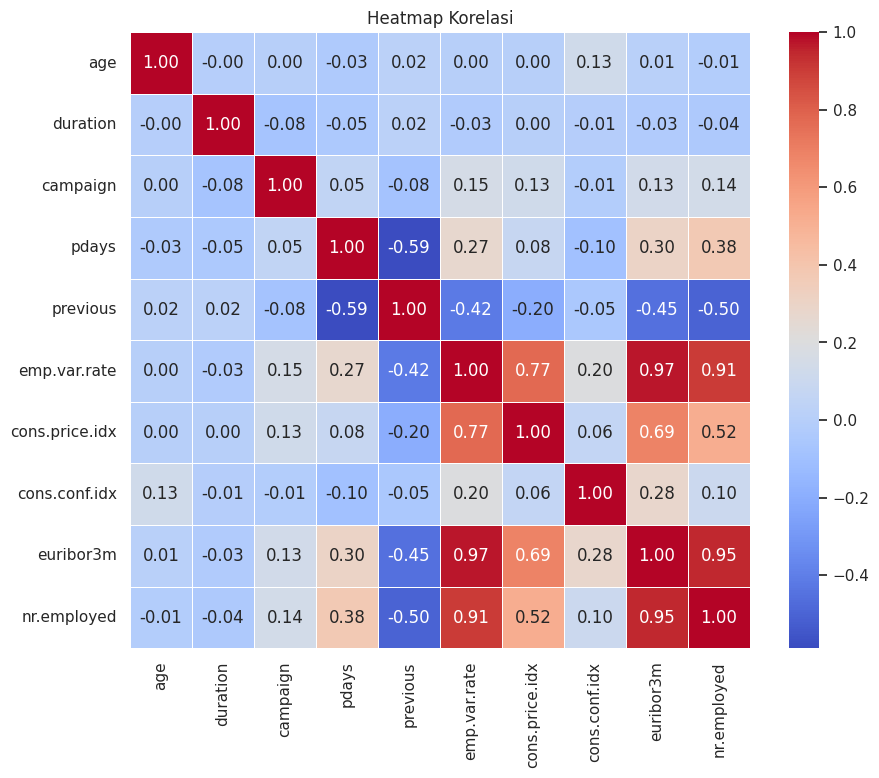

In [ ]:
numerical_cols = train.select_dtypes(include=['number'])

correlation_matrix = numerical_cols.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap Korelasi')
plt.show()


###Variabel Kategorik

Berikutnya kami berencana membuat visualisasi stacked bar chart untuk distribusi kategori berdasarkan target y pada variabel kategorik. Hal ini dilakukan dengan tujuan sebagai berikut


1.   Memahami distribusi kategori variabel kategorik berdasarkan target y
2.   mengidentifikasi pola atau perbedaan antar kategori yang lebih cenderung pada target tertentu
3.   Identifikasi ketidakseimbangan model
4.   Memvisualisasikan proporsi kategori



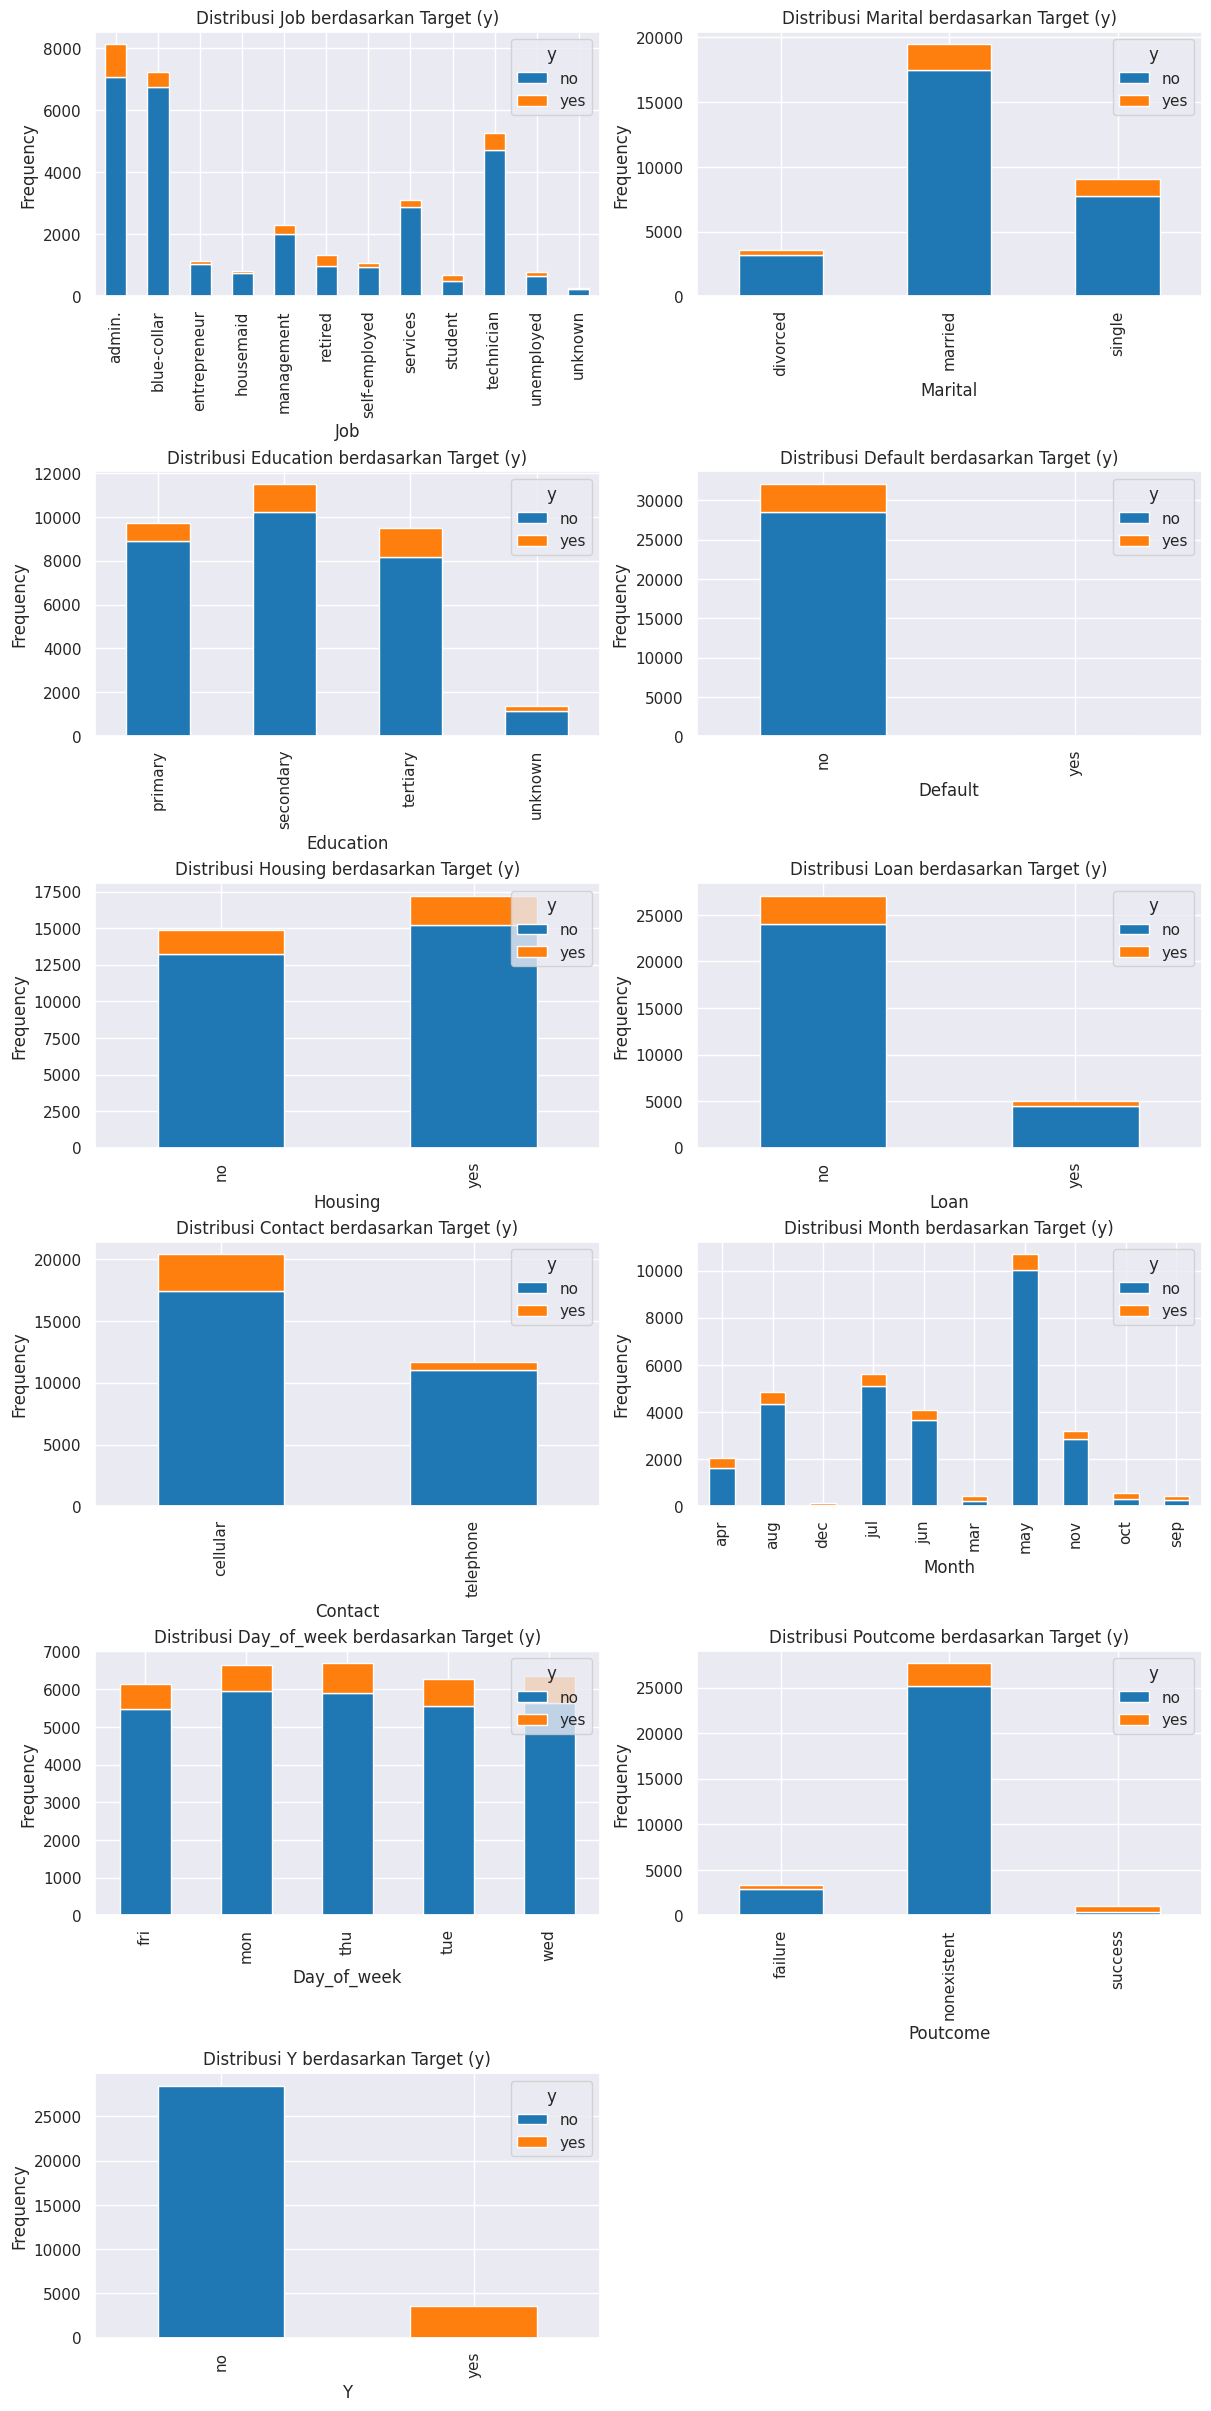

In [ ]:
categorical_variables = list(cat_data.columns)

ncols = 2
nrows = (len(categorical_variables) // ncols) + (len(categorical_variables) % ncols > 0)
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12, 4 * nrows), constrained_layout=True)
axes = axes.flatten()

for i, var in enumerate(categorical_variables):
    crosstab = pd.crosstab(train[var], train['y'])

    crosstab.plot(kind='bar', stacked=True, ax=axes[i], legend=True, color=['#1f77b4', '#ff7f0e'])
    axes[i].set_title(f"Distribusi {var.capitalize()} berdasarkan Target (y)")
    axes[i].set_xlabel(var.capitalize())
    axes[i].set_ylabel("Frequency")
    axes[i].legend(title="y", loc="upper right")

if len(categorical_variables) < len(axes):
    for j in range(len(categorical_variables), len(axes)):
        fig.delaxes(axes[j])

plt.show()

**INTERPRETASI**



1.   Data untuk variabel kategorik menunjukan adanya masalah imbalanced data yang signifikan yang dapat dilihat pada hampir semua variabel kategorik, jumlah individu dengan target y = no jauh lebih besar ketimbang jumlah individu dengan target y = yes

2.   Adanya pola spesifik antara variabel dengan target y, contohnya pada variabel poutcome dimana kategori sukses memiliki kontribusi yang lebih tinggi pada y = yes. Ini menunjukan bahwa pelanggan yang berhasil terlibat dalam kampanye sebelumnya lebih cenderung berlangganan lagi



### Variabel Numerik

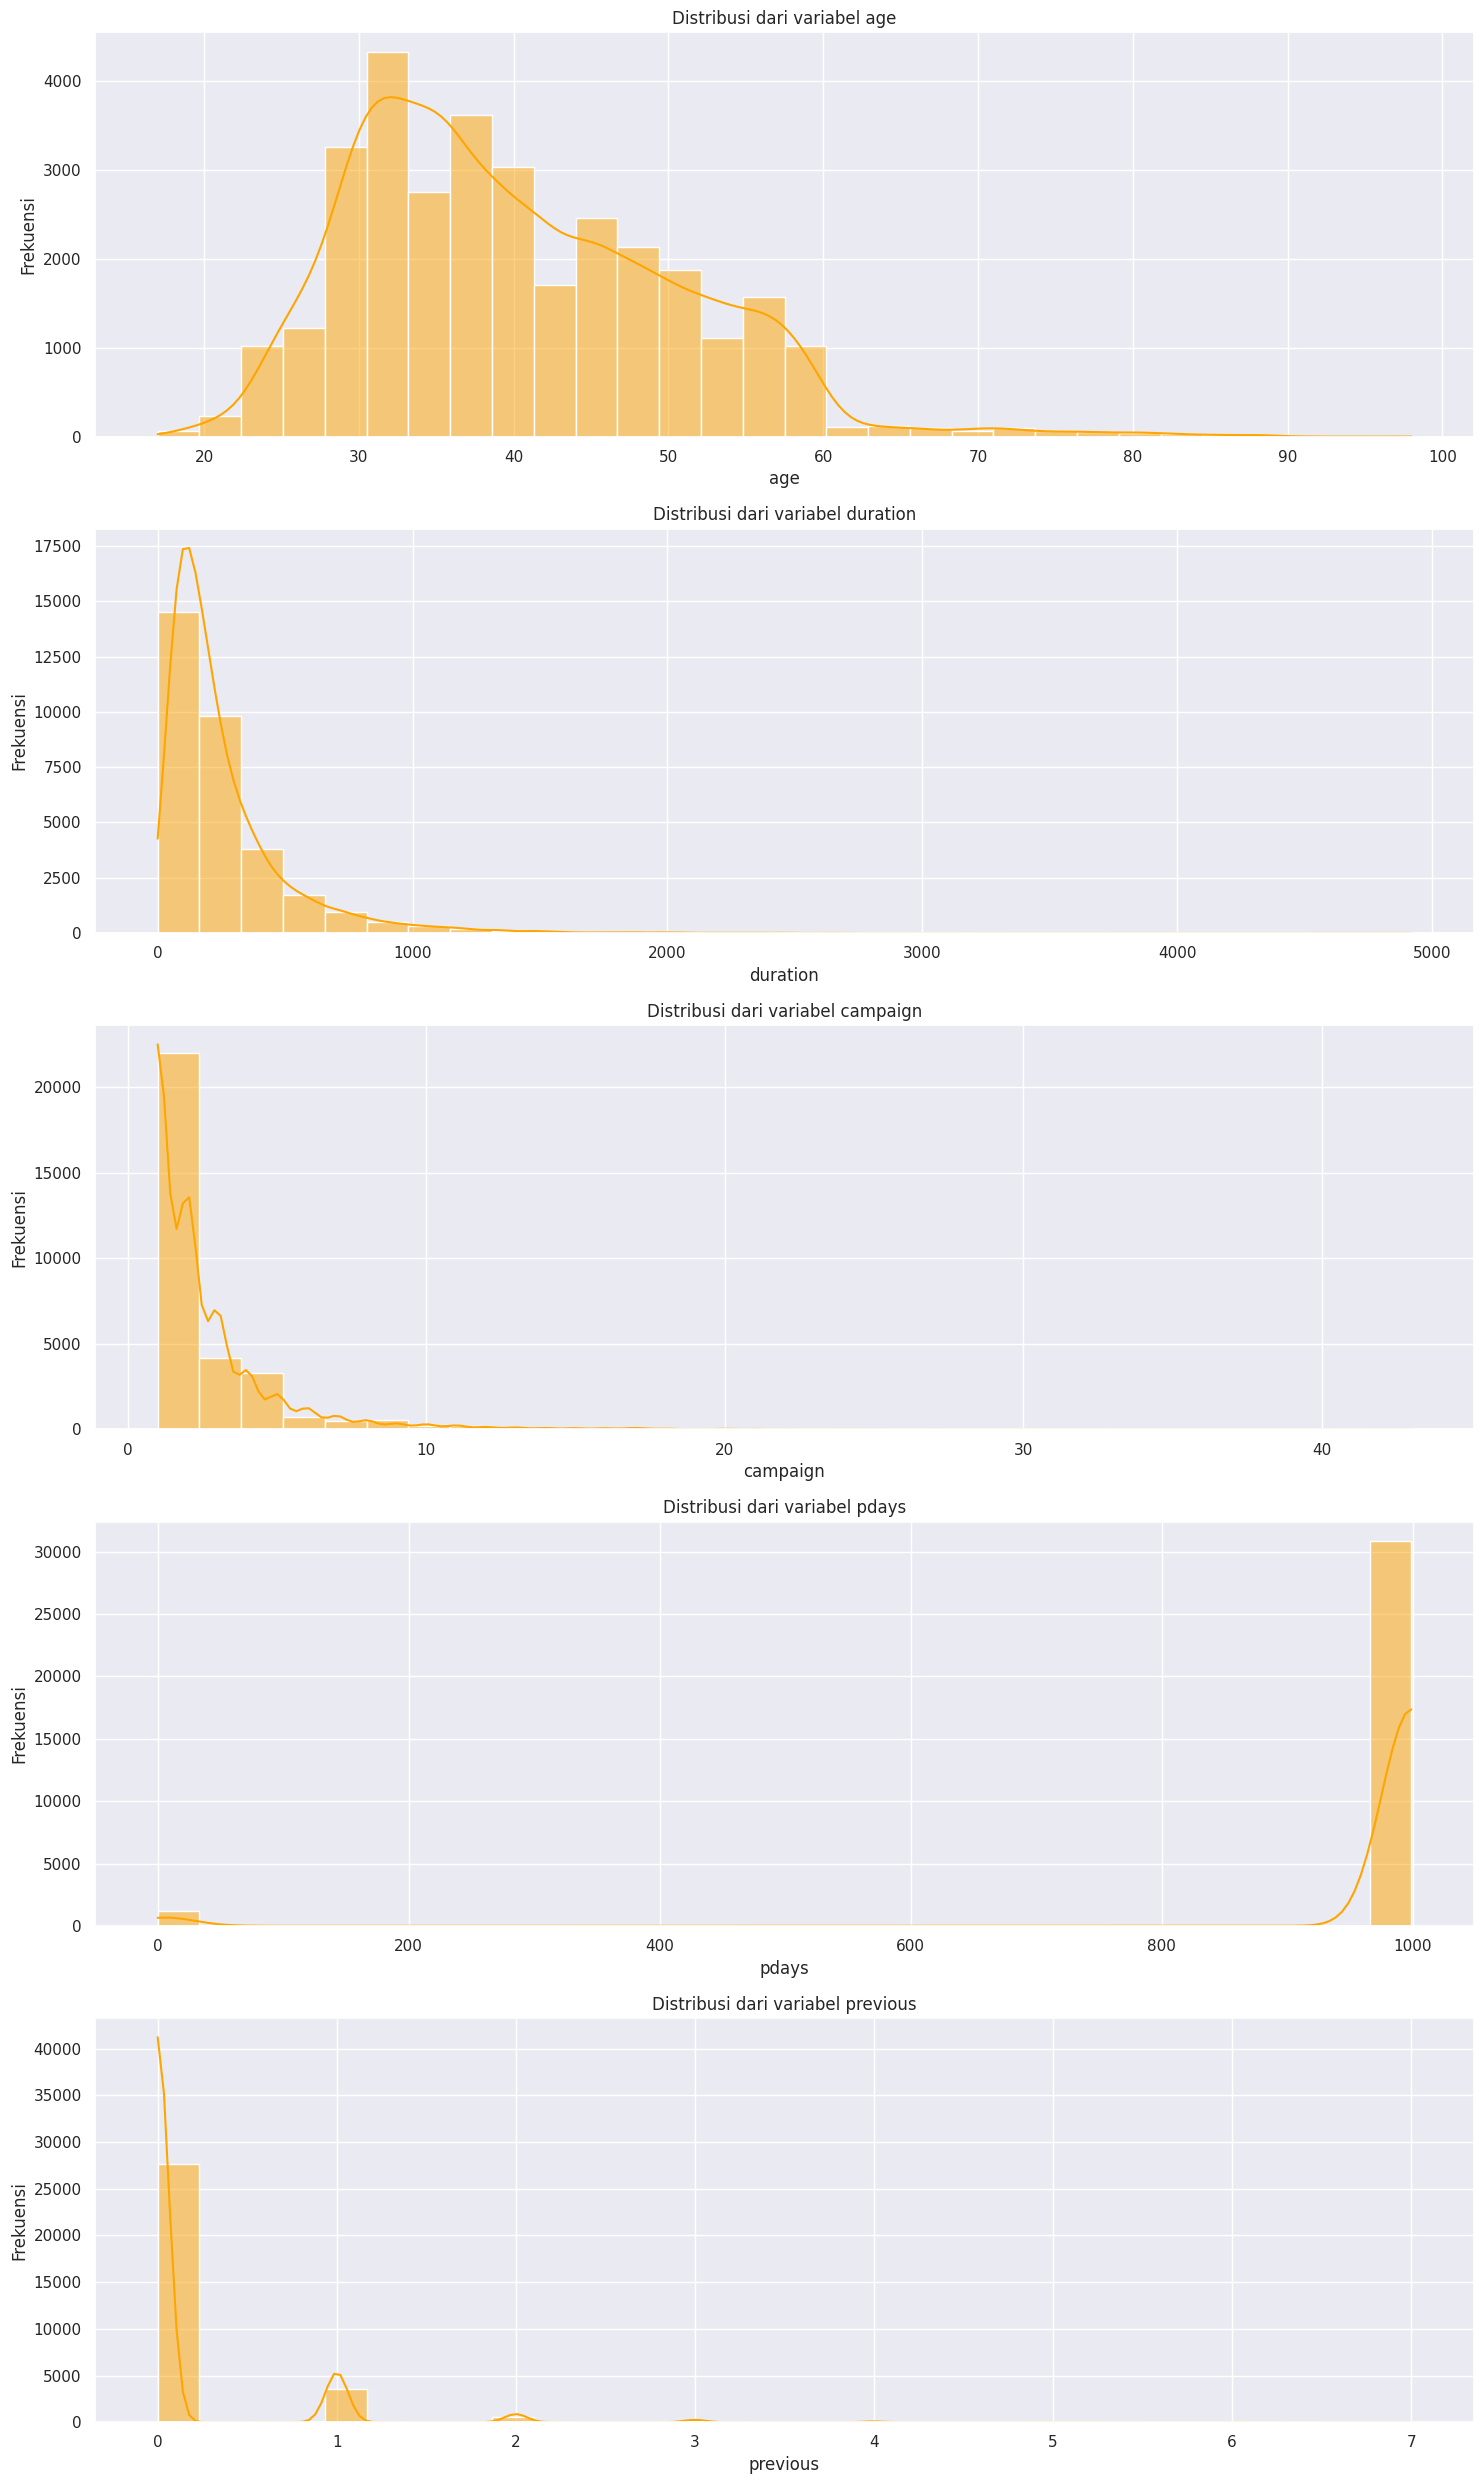

In [ ]:
variabel_numerik = ['age', 'duration', 'campaign', 'pdays', 'previous']

fig, axes = plt.subplots(5, 1, figsize=(15, 25))

for idx, feature in enumerate(variabel_numerik):
    row, col = divmod(idx, 2)
    sns.histplot(train[feature], kde=True, bins=30, color='orange', ax=axes[idx])
    axes[idx].set_title(f'Distribusi dari variabel {feature}')
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('Frekuensi')

plt.tight_layout()
plt.show()


In [ ]:
fig=px.box(train,x='y',y='duration', color='y',template='simple_white',color_discrete_sequence=['Red','green'],title='Box Plot Duration dan Deposito')
fig.update_layout(title_x=0.5,legend_title_text="<b>Term Deposit")
fig.show()

Berdasarkan box plot di atas, terlihat jelas bahwa durasi telepon mempengaruhi klien yang akan melakukan deposito. Hal ini dapat dibuktikan lebih lanjut dengan feature importance setelah model klasifikasi sudah dibuat.

###Variabel Numerik (Indikator Sosial Ekonomi)

Selanjutnya, akan dilakukan EDA pada variabel yang merupakan indikator sosial ekonomi yaitu `emp.var.rate`, `nr.employed`, `cons.price.idx`, `cons.conf.idx`, `euribor3m`. Input pada kelima variabel ini diobservasi setiap jangka waktu tertentu. Akan dilihat bagaimana pola yang ada pada indikator sosial ekonomi yang mungkin memiliki hubungan terhadap tingkat deposito klien.

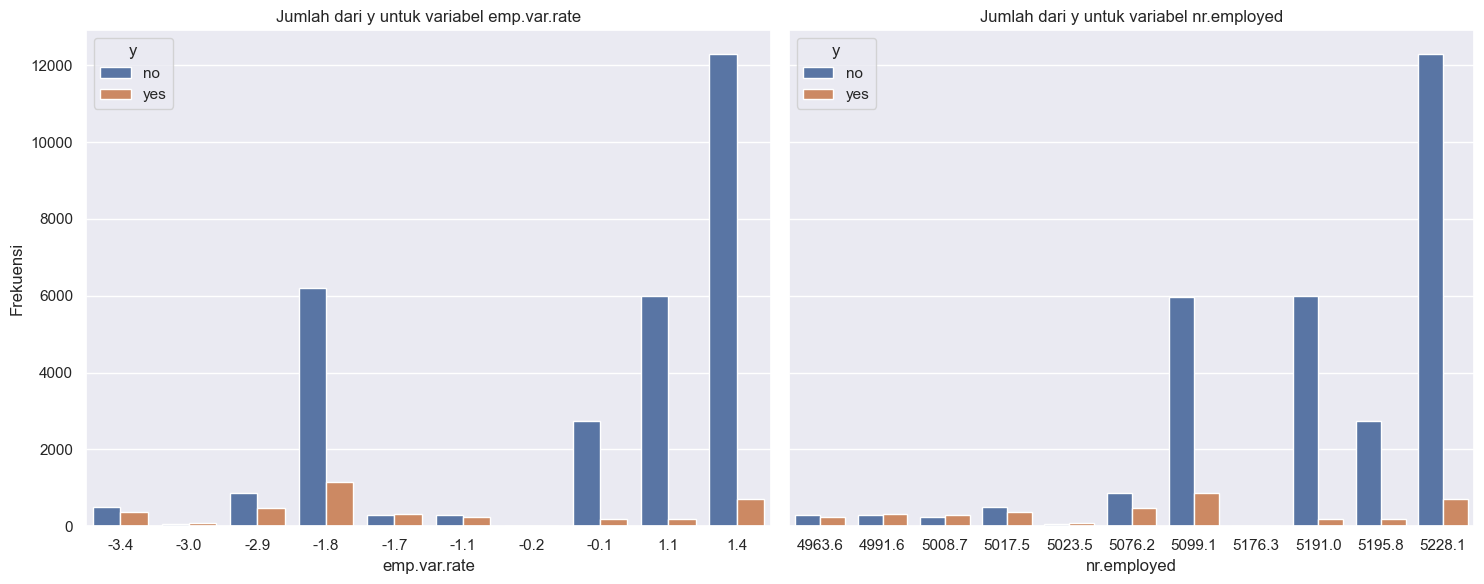

In [ ]:
kategorik_2 = ['emp.var.rate', 'nr.employed']

fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

for i, feature in enumerate(kategorik_2):
    sns.countplot(data=train, x=feature, hue='y', ax=axes[i])
    axes[i].set_title(f'Jumlah dari y untuk variabel {feature}')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Frekuensi')
    axes[i].legend(title='y')

plt.tight_layout()
plt.show()



*   Pada variabel `emp.var.rate`, terdapat frekuensi yang seimbang antara frekuensi deposito pada tingkat variasi ketenagakerjaan tepatnya pada nilai -3.4, -2.9, -1.7, dan -1.1. Sementara itu, terlihat perbedaan yang sangat signifikan pada nilai -1.8, -0.1, 1.1, 1.4. Berdasarkan plot, tingkat variasi ketenagakerjaan yang semakin tinggi akan cenderung meningkatkan frekuensi pelanggan yang tidak melakukan deposito.
*   Variabel `nr.employed` memiliki tren yang sama dengan variabel `emp.var.rate`, yaitu semakin banyak warga negara yang bekerja, semakin tinggi disparitas antara frekuensi klien yang melakukan deposito dan yang tidak melakukan deposito. Terdapat beberapa faktor yang mungkin mempengaruhi tren ini yaitu:
  - Warga negara atau klien yang memiliki pekerjaan stabil merasa lebih aman secara finansial dan kurang membutuhkan menabung atau melakukan deposito.
  - Pendapatan dari bekerja sudah cukup untuk memenuhi kebutuhan sehari-hari.
  - Perubahan prioritas finansial menjadi konsumsi langsung atau investasi lain, seperti membeli rumah atau kendaraan daripada menabung di bank.



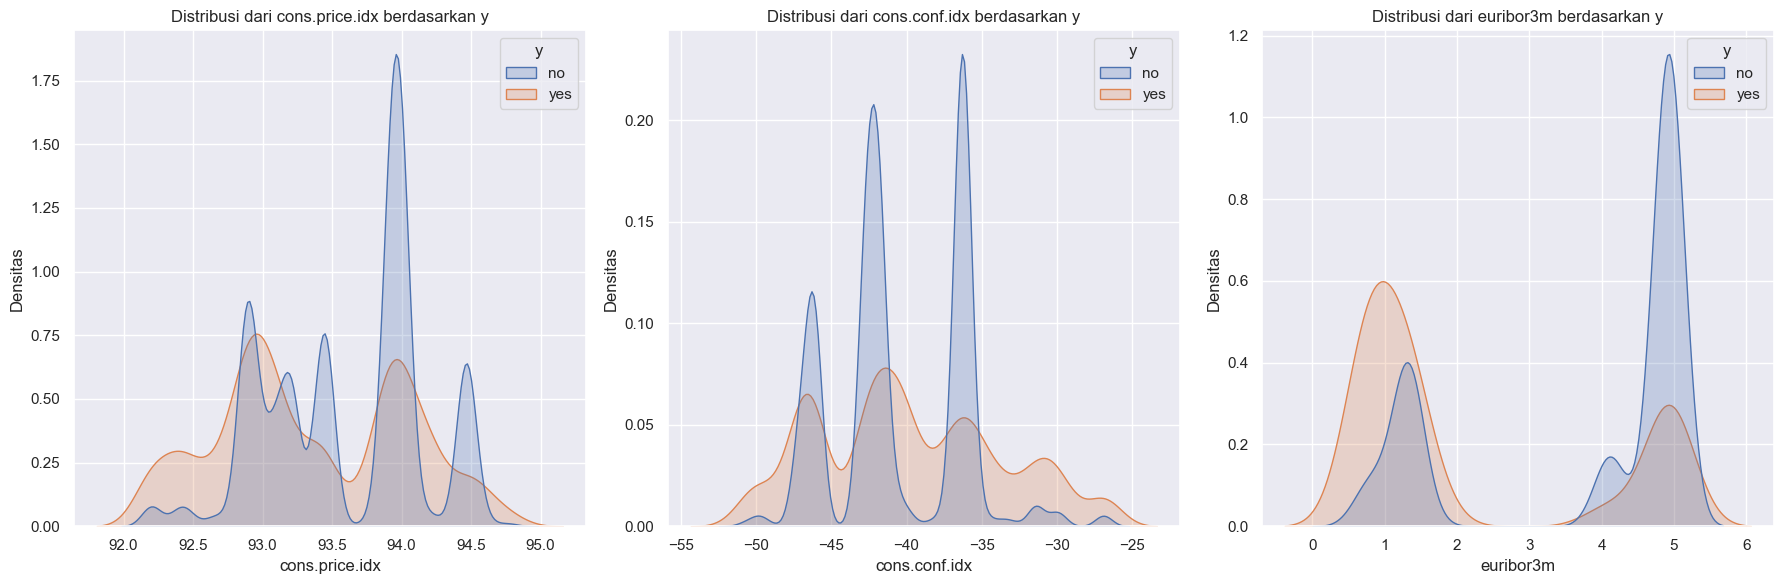

In [ ]:
variabel_kde = ['cons.price.idx', 'cons.conf.idx', 'euribor3m']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, feature in enumerate(variabel_kde):
    sns.kdeplot(data=train, x=feature, hue='y', fill=True, ax=axes[i], common_norm=False)
    axes[i].set_title(f'Distribusi dari {feature} berdasarkan y')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Densitas')

plt.tight_layout()
plt.show()

*   Terlihat bahwa distribusi untuk kelompok yang tidak melakukan deposito lebih terpusat pada rentang nilai sekitar 93.0 hingga 94.0, dengan puncak yang sangat tajam. Sementara itu, klien yang melakukan deposito terlihat memiliki distribusi yang lebih tersebar pada indeks harga konsumen.
*   Klien yang tidak melakukan deposito menunjukkan distribusi kepercayaan konsumen yang lebih tersebar dan negatif, sementara klien yang melakukan deposito lebih memiliki kepercayaan konsumen yang sedikit lebih positif meskipun masih dalam kisaran nilai yang serupa.
*   Dalam hal tingkat Euribor (Euro Interbank Offered Rate), terlihat jelas bahwa klien yang melakukan deposito berada pada rentang yang rendah yaitu 0-2% dengan puncaknya sekitar 1%. Sementara itu, klien yang tidak melakukan deposito berada pada rentang yang tinggi yaitu antara 4-6%, dengan puncaknya yang sangat tajam pada tingkat 5%.

Distribusi ketiga variabel menunjukkan perbedaan pola yang cukup signifikan antara klien yang melakukan deposito dan yang tidak. Klien yang tidak melakukan deposito lebih cenderung berada pada kondisi ekonomi yang lebih stabil, dengan harga konsumen dan kepercayaan konsumen yang lebih tinggi serta suku bunga yang lebih tinggi. Sebaliknya, klien yang melakukan deposito cenderung mengalami kondisi ekonomi yang lebih fluktuatif, dengan harga konsumen dan suku bunga yang lebih rendah.





------------------------------------------------------------------------------------------

## Modelling

Langkah selanjutnya yang dilakukan adalah Modelling. Sebelum masuk ke tahapan ini, terlebih dahulu dilakukan pengecekan proporsi nilai variabel target 'y' (subscribe: "yes" atau "no") pada data.

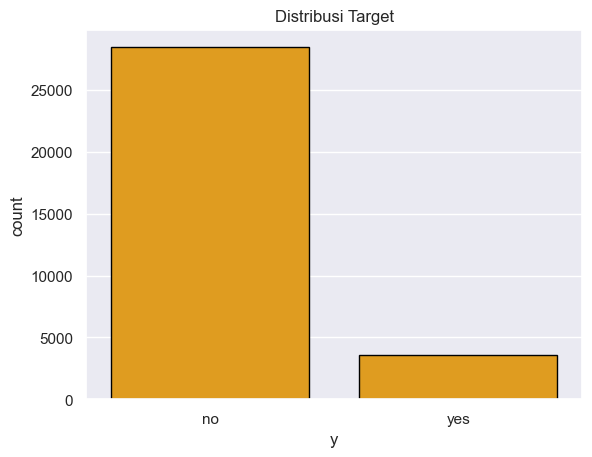

In [ ]:
sns.countplot(x = train['y'] , edgecolor='black', color='orange')
plt.title('Distribusi Target')

plt.show()

Berdasarkan hasil tersebut, ditemukan adanya *imbalance data* karena perbedaan proporsi yang signifikan antara data pada kelas **no** dan **yes**. Data yang termasuk ke dalam kategori **no** jauh lebih banyak dibandingkan data berkategori **yes**.

Masalah *imbalance data* ini perlu diatasi terlebih dahulu sebelum tahap pemodelan untuk meningkatkan performa model. Model akan cenderung memprediksi kelas mayoritas (**no**) dan mengabaikan kelas minoritas (**yes**). Hal ini dapat menghasilkan performa model yang bias terhadap kelas mayoritas, sehingga mengurangi akurasi model dalam memprediksi kategori minoritas.

Beberapa cara untuk menangani kasus *imbalance data* yang akan kami lakukan adalah berikut.
1. SMOTE
2. Random Over Sampling
3. Weighting Class

------------------------------------------------------------------------------------------

### **Using Label Encoder**

#### Preparing the Data

In [ ]:
train1 = train.copy()

In [ ]:
def label_encode_columns(dataframe):
    object_cols = dataframe.select_dtypes(include='object').columns
    label_encoders = {}

    for col in object_cols:
        le = LabelEncoder()
        dataframe[col] = le.fit_transform(dataframe[col])
        label_encoders[col] = le

    return dataframe, label_encoders

def transform_new_data_le(new_data, label_encoders):
    for col, encoder in label_encoders.items():
        if col in new_data.columns:
            new_data[col] = encoder.transform(new_data[col])

    return new_data

train1, label_encoders1 = label_encode_columns(train1)

In [ ]:
train1

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,49,1,1,0,0,0,0,0,7,4,...,4,999,0,1,-0.1,93.200,-42.0,4.120,5195.8,0
1,37,2,1,2,0,0,0,1,7,4,...,2,999,1,0,-0.1,93.200,-42.0,4.120,5195.8,0
2,78,5,1,0,0,0,0,0,3,1,...,1,999,0,1,-1.7,94.215,-40.3,0.870,4991.6,1
3,36,0,1,2,0,1,0,1,6,1,...,2,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
4,59,5,0,2,0,0,0,0,4,3,...,2,999,0,1,-2.9,92.963,-40.8,1.262,5076.2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32945,28,7,2,1,0,1,0,0,3,3,...,1,999,0,1,-1.7,94.215,-40.3,0.876,4991.6,0
32946,52,9,1,1,0,1,0,0,7,0,...,1,999,1,0,-0.1,93.200,-42.0,4.021,5195.8,0
32947,54,0,1,0,0,0,1,0,3,1,...,4,999,0,1,1.4,93.918,-42.7,4.962,5228.1,0
32948,29,0,1,2,0,0,0,1,6,0,...,1,999,0,1,1.1,93.994,-36.4,4.864,5191.0,0


Setelah melakukan

selanjutnya karena semua data sudah menjadi numerik , kita akan melakukan splitting (Untuk melatih dan mengevaluasi)

In [ ]:
X = train1.drop(columns=['y'], axis=1).values
y = train1['y'].values

scaler = StandardScaler()
X = scaler.fit_transform(X)

In [ ]:
X_train , X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2, stratify=y)

### **SMOTE** , **RandomOverSampler** dan **Weighting Class**

Model Analisis Klasifikasi yang paling cocok dan akan digunakan untuk menganalisis data ini adalah Random Forest, Decision Tree, dan Logistic Regression

In [ ]:
models = {
    "Random Forest": RandomForestClassifier(random_state=42, n_jobs=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Logistic Regression" : LogisticRegression(random_state=42, n_jobs=5),
}

#### **1. SMOTE**

SMOTE digunakan untuk menangani masalah imbalanced dataset (ketidakseimbangan kelas) dalam proses klasifikasi. Pada bagian ini, data kelas minoritas (nilai 1) diperbanyak secara sintetis hingga seimbang dengan data kelas mayoritas (nilai 0). Teknik ini membuat model lebih adil dan akurat dalam mengenali kedua kelas.

In [ ]:
smote = SMOTE(random_state=42)
X_train_smote , y_train_smote = smote.fit_resample(X_train, y_train)

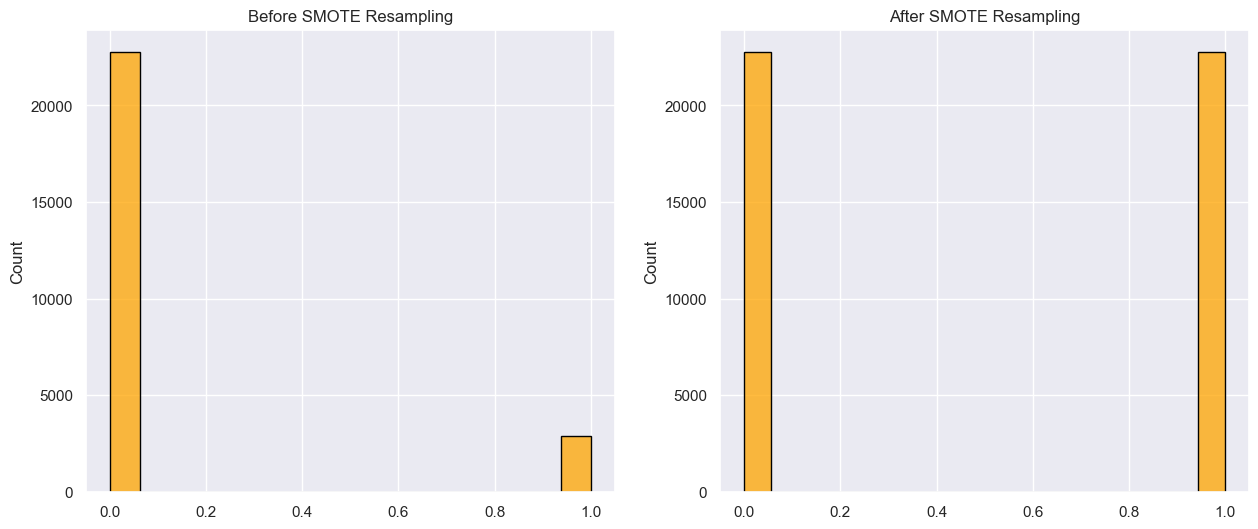

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6))
ax = ax.flatten()

sns.histplot(y_train, color='orange', edgecolor='black', ax=ax[0])
ax[0].set_title('Before SMOTE Resampling')

sns.histplot(y_train_smote, color='orange', edgecolor='black', ax=ax[1])
ax[1].set_title('After SMOTE Resampling')

plt.show()

1. Before SMOTE Resampling menunjukkan ketidakseimbangan kelas. Kelas mayoritas (nilai 0) memiliki jumlah data yang jauh lebih besar dibandingkan kelas minoritas (nilai 1).
2. After SMOTE Resampling menunjukkan hasil setelah SMOTE diterapkan. Data dari kedua kelas kini seimbang, dengan jumlah yang sama untuk kelas mayoritas (0) dan minoritas (1).

Hasil SMOTE menunjukkan bahwa dataset kini seimbang dan siap digunakan untuk pelatihan model klasifikasi. Hal ini sangat penting untuk meningkatkan kinerja model dan mengurangi risiko bias model yang hanya mengenali kelas mayoritas.

In [ ]:
results = []

for model_name, model in tqdm(models.items(), desc="Training Models", unit="model"):
    model.fit(X_train_smote, y_train_smote)

    y_pred = model.predict(X_test)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    f1_cv = cross_val_score(model, X, y, cv=cv, scoring="f1", n_jobs=-1).mean()
    precision_cv = cross_val_score(model, X, y, cv=cv, scoring="precision", n_jobs=-1).mean()
    sensitivity_cv = cross_val_score(model, X, y, cv=cv, scoring="recall", n_jobs=-1).mean()
    accuracy_cv = cross_val_score(model, X, y, cv=cv, scoring="accuracy", n_jobs=-1).mean()

    f1 = f1_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    sensitivity = recall_score(y_test, y_pred)
    accuracy = accuracy_score(y_test, y_pred)

    results.append({
        "Model": model_name,
        "F1 Score Average (CV)": f1_cv,
        "F1 Score (No CV)": f1,
        "Precision Average (CV)": precision_cv,
        "Precision (No CV)": precision,
        "Sensitivity Average (CV)": sensitivity_cv,
        "Sensitivity (No CV)": sensitivity,
        "Accuracy Average (CV)": accuracy_cv,
        "Accuracy (No CV)": accuracy
    })

smote_df = pd.DataFrame(results)

Training Models: 100%|██████████| 3/3 [00:36<00:00, 12.06s/model]


In [ ]:
smote_df

,Model,F1 Score Average (CV),F1 Score (No CV),Precision Average (CV),Precision (No CV),Sensitivity Average (CV),Sensitivity (No CV),Accuracy Average (CV),Accuracy (No CV)
0,Random Forest,0.547323,0.604018,0.636743,0.567600,0.480199,0.645429,0.910573,0.904784
1,Decision Tree,0.498233,0.524734,0.491691,0.478857,0.505130,0.580332,0.885512,0.881720
2,Logistic Regression,0.496577,0.583989,0.658046,0.438499,0.399063,0.873961,0.908983,0.859903


**1. Random Forest:**

- F1 Score (CV): 0.5473 (tertinggi di antara semua model)

- F1 Score (No CV): 0.6040 (tertinggi di antara semua model)

- Precision (CV): 0.6367 (baik, menunjukkan prediksi positif lebih akurat)

- Recall (No CV): 0.6454 (cukup baik)

-Accuracy (CV): 0.9106 (sangat tinggi)

Random Forest memiliki performa terbaik, terutama dalam F1 Score dan Accuracy. Ini menunjukkan model mampu menyeimbangkan precision dan recall dengan baik.

**2. Decision Tree:**

- F1 Score (CV): 0.4982

- Precision (CV): 0.4917 (terendah di antara semua model)

- Recall (No CV): 0.5803 (cukup baik)

- Accuracy (CV): 0.8855

Decision Tree memiliki performa yang lebih rendah dibandingkan Random Forest, terutama dalam hal precision. Namun, akurasinya masih cukup tinggi.

**3. Logistic Regression:**

- F1 Score (CV): 0.4966

- F1 Score (No CV): 0.5839

- Precision (CV): 0.6580 (tertinggi di antara semua model)

- Recall (CV): 0.3991 (terendah)

- Accuracy (CV): 0.9089

Logistic Regression menunjukkan precision tertinggi, namun recall-nya rendah. Ini berarti model lebih fokus pada prediksi positif yang benar, namun kurang baik dalam mendeteksi semua sampel positif.

#### **2. Random Over Sampler**

Metode Random Over Sampler digunakan untuk menangani ketidakseimbangan data pada training set dan meningkatkan jumlah sampel kelas minoritas dengan menduplikasi sampel yang ada hingga distribusi kedua kelas menjadi seimbang.

In [ ]:
ros = RandomOverSampler(random_state=42)
X_train_ros , y_train_ros = ros.fit_resample(X_train, y_train)

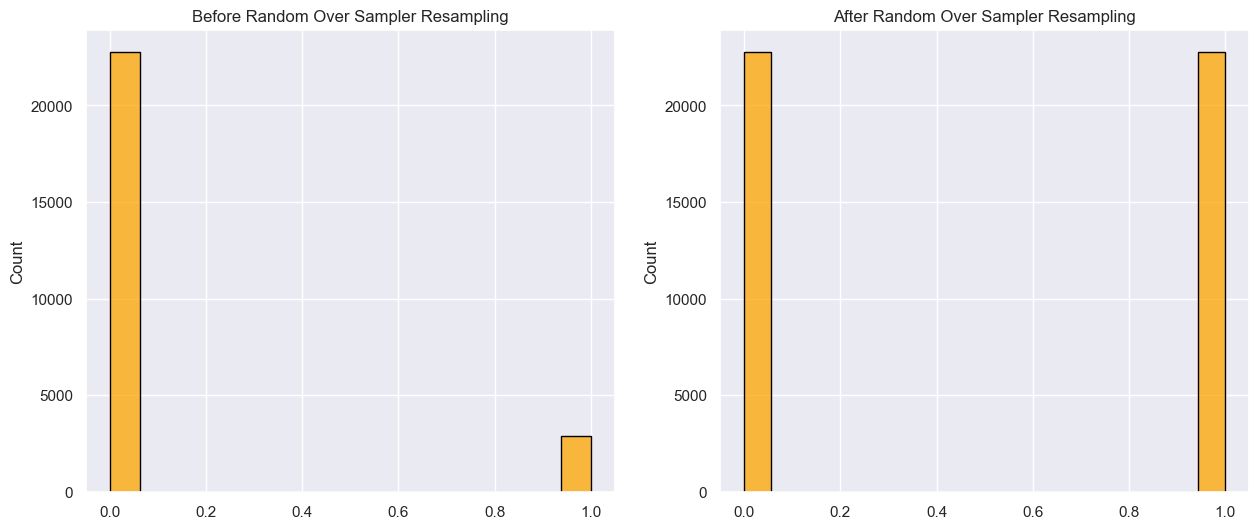

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6))
ax = ax.flatten()

sns.histplot(y_train, color='orange', edgecolor='black', ax=ax[0])
ax[0].set_title('Before Random Over Sampler Resampling')

sns.histplot(y_train_ros, color='orange', edgecolor='black', ax=ax[1])
ax[1].set_title('After Random Over Sampler Resampling')

plt.show()

**1. Before Random Over Sampler Resampling:**

Kelas mayoritas mendominasi data, yang dapat menyebabkan model bias terhadap kelas mayoritas (nilai 0) selama pelatihan dan ketidakseimbangan data dapat mengurangi performa model, terutama untuk mendeteksi kelas minoritas (nilai 1).

**2. After Random Over Sampler Resampling:**

Kelas minoritas memiliki jumlah sampel yang sama dengan kelas mayoritas dan dengan distribusi yang seimbang, model memiliki peluang yang lebih baik untuk belajar pola dari kedua kelas secara adil.

Dengan Random Over Sampler, kelas minoritas diperkuat tanpa kehilangan informasi dari kelas mayoritas. Langkah ini sangat penting untuk mengatasi bias akibat ketidakseimbangan data, terutama ketika menggunakan algoritma seperti Logistic Regression atau Decision Tree yang rentan terhadap distribusi kelas.

In [ ]:
results = []

for model_name, model in tqdm(models.items(), desc="Training Models", unit="model"):
    model.fit(X_train_ros, y_train_ros)

    y_pred = model.predict(X_test)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    f1_cv = cross_val_score(model, X, y, cv=cv, scoring="f1", n_jobs=-1).mean()
    precision_cv = cross_val_score(model, X, y, cv=cv, scoring="precision", n_jobs=-1).mean()
    sensitivity_cv = cross_val_score(model, X, y, cv=cv, scoring="recall", n_jobs=-1).mean()
    accuracy_cv = cross_val_score(model, X, y, cv=cv, scoring="accuracy", n_jobs=-1).mean()

    f1 = f1_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    sensitivity = recall_score(y_test, y_pred)
    accuracy = accuracy_score(y_test, y_pred)

    results.append({
        "Model": model_name,
        "F1 Score Average (CV)": f1_cv,
        "F1 Score (No CV)": f1,
        "Precision Average (CV)": precision_cv,
        "Precision (No CV)": precision,
        "Sensitivity Average (CV)": sensitivity_cv,
        "Sensitivity (No CV)": sensitivity,
        "Accuracy Average (CV)": accuracy_cv,
        "Accuracy (No CV)": accuracy
    })

ros_df = pd.DataFrame(results)

Training Models: 100%|██████████| 3/3 [00:32<00:00, 10.69s/model]


In [ ]:
ros_df

,Model,F1 Score Average (CV),F1 Score (No CV),Precision Average (CV),Precision (No CV),Sensitivity Average (CV),Sensitivity (No CV),Accuracy Average (CV),Accuracy (No CV)
0,Random Forest,0.547323,0.582471,0.636743,0.580468,0.480199,0.584488,0.910573,0.905719
1,Decision Tree,0.498233,0.479491,0.491691,0.489884,0.505130,0.469529,0.885512,0.885305
2,Logistic Regression,0.496577,0.578182,0.658046,0.430311,0.399063,0.880886,0.908983,0.855384


1. Random Forest adalah model terbaik berdasarkan sebagian besar metrik karena memiliki score yang lebih tinggi

- F1 Score tertinggi: 0.5473 (CV) dan 0.5825 (No CV).

- Precision tertinggi: 0.6367 (CV).

- Accuracy terbaik: 0.9106 (CV).

2. Decision Tree memiliki kinerja yang lebih rendah dibanding Random Forest. Karena F1 Score dan Precision rendah, namun Recall/Sensitivity-nya lebih tinggi dibanding Logistic Regression.

3. Logistic Regression menunjukkan hasil Precision yang lebih tinggi saat menggunakan CV (0.6580), tetapi memiliki Sensitivity dan Accuracy yang lebih rendah dibanding Random Forest.

#### **3. Weighting Class Method**

Weighting Class Method dalam model-model klasifikasi adalah untuk mengatasi masalah ketidakseimbangan kelas dalam data. Dengan memberikan bobot yang sama pada setiap kelas, model akan berusaha untuk memprediksi kelas minoritas dengan lebih baik.

In [ ]:
models_weighted = {
    "Random Forest": RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    "Logistic Regression" : LogisticRegression(random_state=42, class_weight='balanced', n_jobs=5),
}

In [ ]:
results = []

for model_name, model in tqdm(models_weighted.items(), desc="Training Models", unit="model"):
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    f1_cv = cross_val_score(model, X, y, cv=cv, scoring="f1", n_jobs=-1).mean()
    precision_cv = cross_val_score(model, X, y, cv=cv, scoring="precision", n_jobs=-1).mean()
    sensitivity_cv = cross_val_score(model, X, y, cv=cv, scoring="recall", n_jobs=-1).mean()
    accuracy_cv = cross_val_score(model, X, y, cv=cv, scoring="accuracy", n_jobs=-1).mean()

    f1 = f1_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    sensitivity = recall_score(y_test, y_pred)
    accuracy = accuracy_score(y_test, y_pred)

    results.append({
        "Model": model_name,
        "F1 Score Average (CV)": f1_cv,
        "F1 Score (No CV)": f1,
        "Precision Average (CV)": precision_cv,
        "Precision (No CV)": precision,
        "Sensitivity Average (CV)": sensitivity_cv,
        "Sensitivity (No CV)": sensitivity,
        "Accuracy Average (CV)": accuracy_cv,
        "Accuracy (No CV)": accuracy
    })

weight_df = pd.DataFrame(results)

Training Models: 100%|██████████| 3/3 [00:35<00:00, 11.84s/model]


In [ ]:
weight_df

,Model,F1 Score Average (CV),F1 Score (No CV),Precision Average (CV),Precision (No CV),Sensitivity Average (CV),Sensitivity (No CV),Accuracy Average (CV),Accuracy (No CV)
0,Random Forest,0.512658,0.504626,0.648201,0.642398,0.424263,0.415512,0.909233,0.908213
1,Decision Tree,0.492913,0.458755,0.511596,0.480303,0.475772,0.439058,0.889813,0.883435
2,Logistic Regression,0.571436,0.576609,0.426850,0.428571,0.864301,0.880886,0.854093,0.854449


1. **Random Forest**
  Menunjukan hasil F1 score dan sesitivity yang lebih rendah dibandingkan dengan Logistis Regression, tetapi memiliki nilai precision score yang lebih unggul dibandingkan Logistic Regression (0.648201).
  Precision (CV) = 0.648201 dan Accuracy (CV) = 0.909233, tertinggi dibandingkan model lain dengan metode penanganan Weighting Class. Akan tetapi, nilai Sensitivity/Recall-nya (0.423263) paling rendah dibandingkan model lain. Hal ini menunjukkan masih terdapat adanya kecenderungan model dalam memprediksi kelas minoritas menjadi kelas mayoritas.

2. **Decision Tree**
  Memiliki kinerja yang lebih rendah dibanding model yang lain. Memiliki F1 Score, Precision rendah, dan Sensitivity yang rendah. Akan tetapi, Decision Tree memiliki akurasi yang cukup tinggi, bahkan lebih tinggi daripada Logistic Regression.

3. **Logistic Regression**
 Merupakan model terbaik berdasarkan sebagian besar data metrik karena memiliki nilai  tertinggi F1 Score (CV) = 0.571436, F1 Score (No CV) = 0.576609, dan Sensitivity (CV) = 0.864301. Hal ini mengindikasikan bahwa Logistic Regression memiliki kemampuan yang lebih baik dalam mendeteksi kelas minoritas dibandingkan dengan dua model lainnya. Akan tetapi, nilai Precision dan Accuracy untuk model ini adalah yang paling rendah.

#### Compare All Method with Label Encoder

In [ ]:
smote_df['Type'] = 'SMOTE'
ros_df['Type'] = 'Random Over Sampler'
weight_df['Type'] = 'Weighted'

compare_df = pd.concat([smote_df, ros_df, weight_df], axis=0)
compare_df

,Model,F1 Score Average (CV),F1 Score (No CV),Precision Average (CV),Precision (No CV),Sensitivity Average (CV),Sensitivity (No CV),Accuracy Average (CV),Accuracy (No CV),Type
0,Random Forest,0.547323,0.604018,0.636743,0.567600,0.480199,0.645429,0.910573,0.904784,SMOTE
1,Decision Tree,0.498233,0.524734,0.491691,0.478857,0.505130,0.580332,0.885512,0.881720,SMOTE
2,Logistic Regression,0.496577,0.583989,0.658046,0.438499,0.399063,0.873961,0.908983,0.859903,SMOTE
0,Random Forest,0.547323,0.582471,0.636743,0.580468,0.480199,0.584488,0.910573,0.905719,Random Over Sampler
1,Decision Tree,0.498233,0.479491,0.491691,0.489884,0.505130,0.469529,0.885512,0.885305,Random Over Sampler
2,Logistic Regression,0.496577,0.578182,0.658046,0.430311,0.399063,0.880886,0.908983,0.855384,Random Over Sampler
0,Random Forest,0.512658,0.504626,0.648201,0.642398,0.424263,0.415512,0.909233,0.908213,Weighted
1,Decision Tree,0.492913,0.458755,0.511596,0.480303,0.475772,0.439058,0.889813,0.883435,Weighted
2,Logistic Regression,0.571436,0.576609,0.426850,0.428571,0.864301,0.880886,0.854093,0.854449,Weighted


**1. Pengaruh Teknik Penanganan Ketidakseimbangan Data**

 * SMOTE: Teknik SMOTE umumnya memberikan hasil yang cukup baik dalam meningkatkan kinerja model pada kelas minoritas. Namun, dalam kasus ini, peningkatan kinerja tidak terlalu signifikan dibandingkan dengan teknik lainnya.

 * Random Over Sampling: Teknik ini juga cukup efektif dalam mengatasi ketidakseimbangan kelas, terutama untuk model Random Forest dan Decision Tree.

 * Weighted: Teknik ini memberikan hasil yang bervariasi tergantung pada model. Untuk model Logistic Regression, teknik ini memberikan peningkatan kinerja yang cukup signifikan pada metrik recall.

**2. Perbandingan Kinerja Model:**
 * Random Forest: Model Random Forest secara umum memberikan kinerja yang cukup baik, terutama dalam hal akurasi. Model ini juga cukup robust terhadap ketidakseimbangan kelas.
 * Decision Tree: Kinerja Decision Tree sedikit lebih rendah dibandingkan dengan Random Forest, terutama dalam hal presisi.
 * Logistic Regression: Kinerja Logistic Regression bervariasi tergantung pada teknik penanganan ketidakseimbangan data yang digunakan. Namun, secara umum, model ini memberikan hasil yang cukup baik dalam hal recall.

Berdasarkan hasil yang ditampilkan dapat disimpulkan bahwa tidak ada teknik penanganan ketidakseimbangan data yang secara signifikan lebih baik dari yang lain, kinerja model sangat tergantung pada karakteristik dataset dan model yang digunakan.
Random Forest merupakan model yang cukup serbaguna dan memberikan kinerja yang baik dalam berbagai situasi dan Weighted merupakan teknik yang dapat memberikan peningkatan kinerja yang signifikan untuk model Logistic Regression, terutama dalam hal recall.


---------------------------------------------

### **Using One Hot Encoding**

One-hot encoding adalah teknik yang digunakan dalam pemrosesan data untuk mengubah data kategorikal menjadi representasi numerik yang dapat dipahami oleh algoritma machine learning.

#### Preparing the Data

In [ ]:
train2 = train.copy()

In [ ]:
def onh_encode_columns(dataframe):
    object_cols = dataframe.select_dtypes(include='object').columns
    label_encoders = {}
    one_hot_cols = []
    one_hot_structures = {}

    for col in object_cols:
        if dataframe[col].nunique() > 2:
            one_hot_encoded = pd.get_dummies(dataframe[col], prefix=col)
            one_hot_structures[col] = one_hot_encoded.columns
            dataframe = pd.concat([dataframe, one_hot_encoded], axis=1)
            dataframe.drop(columns=[col], inplace=True)
            one_hot_cols.append(col)
        else:
            le = LabelEncoder()
            dataframe[col] = le.fit_transform(dataframe[col])
            label_encoders[col] = le

    return dataframe, label_encoders, one_hot_cols, one_hot_structures

def transform_new_data_onh(new_data, label_encoders, one_hot_columns, one_hot_structures):
    for col, encoder in label_encoders.items():
        if col in new_data.columns:
            new_data[col] = new_data[col].apply(
                lambda x: encoder.transform([x])[0] if x in encoder.classes_ else -1
            )

    for col in one_hot_columns:
        if col in new_data.columns:
            one_hot_encoded = pd.get_dummies(new_data[col], prefix=col)
            for col_name in one_hot_structures[col]:
                if col_name not in one_hot_encoded.columns:
                    one_hot_encoded[col_name] = 0
            new_data = pd.concat([new_data, one_hot_encoded], axis=1)
            new_data.drop(columns=[col], inplace=True)

    return new_data

train2, label_encoders2, one_hot_columns2, one_hot_structures2 = onh_encode_columns(train2)
train2.replace({True: 1, False: 0}, inplace=True)

In [ ]:
train2

,age,default,housing,loan,contact,duration,campaign,pdays,previous,emp.var.rate,...,month_oct,month_sep,day_of_week_fri,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent,poutcome_success
0,49,0,0,0,0,227,4,999,0,-0.1,...,0,0,0,0,0,0,1,0,1,0
1,37,0,0,0,1,202,2,999,1,-0.1,...,0,0,0,0,0,0,1,1,0,0
2,78,0,0,0,0,1148,1,999,0,-1.7,...,0,0,0,1,0,0,0,0,1,0
3,36,0,1,0,1,120,2,999,0,1.1,...,0,0,0,1,0,0,0,0,1,0
4,59,0,0,0,0,368,2,999,0,-2.9,...,0,0,0,0,0,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32945,28,0,1,0,0,192,1,999,0,-1.7,...,0,0,0,0,0,1,0,0,1,0
32946,52,0,1,0,0,64,1,999,1,-0.1,...,0,0,1,0,0,0,0,1,0,0
32947,54,0,0,1,0,131,4,999,0,1.4,...,0,0,0,1,0,0,0,0,1,0
32948,29,0,0,0,1,165,1,999,0,1.1,...,0,0,1,0,0,0,0,0,1,0


Pada hasil dataset train2 ini data kategorikal sudah direpresentasikan menjadi numerik. Semua nilai True dalam dataset train2 diganti dengan nilai 1, dan semua nilai False diganti dengan nilai 0. Ini dilakukan untuk memastikan bahwa semua data dalam dataset adalah numerik.

selanjutnya karena semua data sudah menjadi numerik , kita akan melakukan splitting (Untuk melatih dan mengevaluasi)

In [ ]:
X = train2.drop(columns=['y'], axis=1).values
y = train2['y'].values

scaler2 = StandardScaler()
X = scaler2.fit_transform(X)

In [ ]:
X_train , X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2, stratify=y)

### **SMOTE** , **RandomOverSampler** dan **Weighting Class**

In [ ]:
models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Logistic Regression" : LogisticRegression(random_state=42)
}

#### **1. SMOTE**

In [ ]:
smote2 = SMOTE(random_state=42)
X_train_smote , y_train_smote = smote2.fit_resample(X_train, y_train)

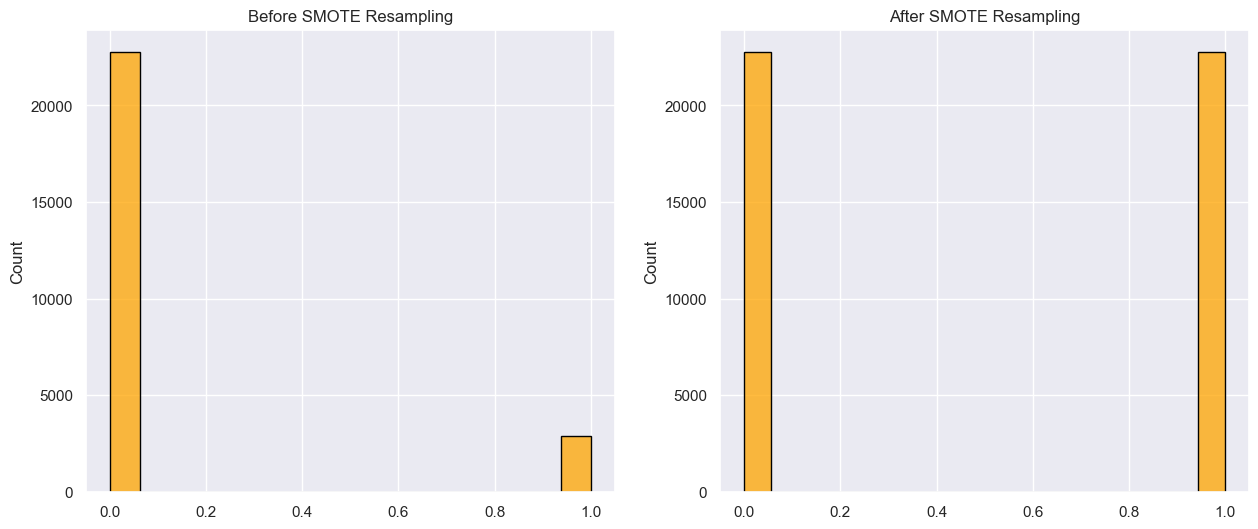

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6))
ax = ax.flatten()

sns.histplot(y_train, color='orange', edgecolor='black', ax=ax[0])
ax[0].set_title('Before SMOTE Resampling')

sns.histplot(y_train_smote, color='orange', edgecolor='black', ax=ax[1])
ax[1].set_title('After SMOTE Resampling')

plt.show()

1. Before SMOTE Resampling menunjukkan ketidakseimbangan kelas. Kelas mayoritas (nilai 0) memiliki jumlah data yang jauh lebih besar dibandingkan kelas minoritas (nilai 1).
2. After SMOTE Resampling menunjukkan hasil setelah SMOTE diterapkan. Data dari kedua kelas kini seimbang, dengan jumlah yang sama untuk kelas mayoritas (0) dan minoritas (1).

Hasil SMOTE menunjukkan bahwa dataset kini seimbang dan siap digunakan untuk pelatihan model klasifikasi. Hal ini sangat penting untuk meningkatkan kinerja model dan mengurangi risiko bias model yang hanya mengenali kelas mayoritas.

In [ ]:
results = []

for model_name, model in tqdm(models.items(), desc="Training Models", unit="model"):
    model.fit(X_train_smote, y_train_smote)

    y_pred = model.predict(X_test)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    f1_cv = cross_val_score(model, X, y, cv=cv, scoring="f1", n_jobs=-1).mean()
    precision_cv = cross_val_score(model, X, y, cv=cv, scoring="precision", n_jobs=-1).mean()
    sensitivity_cv = cross_val_score(model, X, y, cv=cv, scoring="recall", n_jobs=-1).mean()
    accuracy_cv = cross_val_score(model, X, y, cv=cv, scoring="accuracy", n_jobs=-1).mean()

    f1 = f1_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    sensitivity = recall_score(y_test, y_pred)
    accuracy = accuracy_score(y_test, y_pred)

    results.append({
        "Model": model_name,
        "F1 Score Average (CV)": f1_cv,
        "F1 Score (No CV)": f1,
        "Precision Average (CV)": precision_cv,
        "Precision (No CV)": precision,
        "Sensitivity Average (CV)": sensitivity_cv,
        "Sensitivity (No CV)": sensitivity,
        "Accuracy Average (CV)": accuracy_cv,
        "Accuracy (No CV)": accuracy
    })

smote_df2 = pd.DataFrame(results)

Training Models: 100%|██████████| 3/3 [00:55<00:00, 18.47s/model]


In [ ]:
smote_df2

,Model,F1 Score Average (CV),F1 Score (No CV),Precision Average (CV),Precision (No CV),Sensitivity Average (CV),Sensitivity (No CV),Accuracy Average (CV),Accuracy (No CV)
0,Random Forest,0.538475,0.577533,0.645865,0.574760,0.461922,0.580332,0.910885,0.904472
1,Decision Tree,0.498813,0.497749,0.490115,0.464586,0.507897,0.536011,0.885138,0.878292
2,Logistic Regression,0.506009,0.590867,0.653414,0.445225,0.413187,0.878116,0.909233,0.863176


1. Random Forest memiliki kinerja yang lebih rendah dibandingkan Logistic Regression karena memiliki nilai No CV dan precision yang lebih rendah, namun memiliki nilai CV yang paling tinggi (0.538475)

2. Decision Tree memiliki kinerja yang lebih rendah dibanding Logistic Regression. Karena F1 Score dan Precision rendah, namun Sensitivity-nya lebih tinggi dibanding Logistic Regression.

3. Logistic Regression merupakan model terbaik berdasarkan sebagian besar metrik karena memiliki skor tertinggi untuk No CV (0.590867) dan precision (0.653414).

#### **2. Random Over Sampler**

In [ ]:
ros2 = RandomOverSampler(random_state=42)
X_train_ros , y_train_ros = ros2.fit_resample(X_train, y_train)

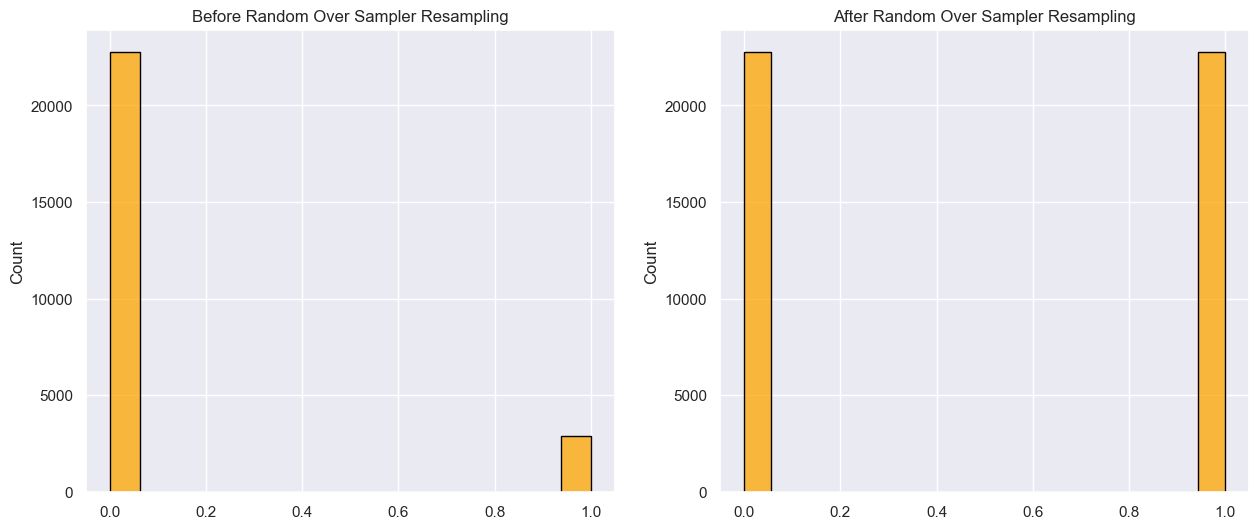

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6))
ax = ax.flatten()

sns.histplot(y_train, color='orange', edgecolor='black', ax=ax[0])
ax[0].set_title('Before Random Over Sampler Resampling')

sns.histplot(y_train_ros, color='orange', edgecolor='black', ax=ax[1])
ax[1].set_title('After Random Over Sampler Resampling')

plt.show()

**1. Before Random Over Sampler Resampling:**

Kelas mayoritas mendominasi data, yang dapat menyebabkan model bias terhadap kelas mayoritas (nilai 0) selama pelatihan dan ketidakseimbangan data dapat mengurangi performa model, terutama untuk mendeteksi kelas minoritas (nilai 1).

**2. After Random Over Sampler Resampling:**

Kelas minoritas memiliki jumlah sampel yang sama dengan kelas mayoritas dan dengan distribusi yang seimbang, model memiliki peluang yang lebih baik untuk belajar pola dari kedua kelas secara adil.

In [ ]:
results = []

for model_name, model in tqdm(models.items(), desc="Training Models", unit="model"):
    model.fit(X_train_ros, y_train_ros)

    y_pred = model.predict(X_test)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    f1_cv = cross_val_score(model, X, y, cv=cv, scoring="f1", n_jobs=-1).mean()
    precision_cv = cross_val_score(model, X, y, cv=cv, scoring="precision", n_jobs=-1).mean()
    sensitivity_cv = cross_val_score(model, X, y, cv=cv, scoring="recall", n_jobs=-1).mean()
    accuracy_cv = cross_val_score(model, X, y, cv=cv, scoring="accuracy", n_jobs=-1).mean()

    f1 = f1_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    sensitivity = recall_score(y_test, y_pred)
    accuracy = accuracy_score(y_test, y_pred)

    results.append({
        "Model": model_name,
        "F1 Score Average (CV)": f1_cv,
        "F1 Score (No CV)": f1,
        "Precision Average (CV)": precision_cv,
        "Precision (No CV)": precision,
        "Sensitivity Average (CV)": sensitivity_cv,
        "Sensitivity (No CV)": sensitivity,
        "Accuracy Average (CV)": accuracy_cv,
        "Accuracy (No CV)": accuracy
    })

ros_df2 = pd.DataFrame(results)

Training Models: 100%|██████████| 3/3 [00:49<00:00, 16.46s/model]


In [ ]:
ros_df2

,Model,F1 Score Average (CV),F1 Score (No CV),Precision Average (CV),Precision (No CV),Sensitivity Average (CV),Sensitivity (No CV),Accuracy Average (CV),Accuracy (No CV)
0,Random Forest,0.538475,0.571227,0.645865,0.581897,0.461922,0.560942,0.910885,0.905252
1,Decision Tree,0.498813,0.487737,0.490115,0.493617,0.507897,0.481994,0.885138,0.886084
2,Logistic Regression,0.506009,0.585121,0.653414,0.436351,0.413187,0.887812,0.909233,0.858345


1. Random Forest memiliki kinerja yang lebih rendah dibandingkan Logistic Regression karena memiliki nilai No CV dan precision yang lebih rendah, namun memiliki nilai CV yang paling tinggi (0.538475)

2. Decision Tree memiliki kinerja yang lebih rendah dibanding Logistic Regression. Karena F1 Score dan Precision rendah, namun Sensitivity-nya lebih tinggi dibanding Logistic Regression.

3. Logistic Regression merupakan model terbaik berdasarkan sebagian besar metrik karena memiliki skor tertinggi untuk No CV (0.585121) dan precision (0.653414).

#### **3. Weighting Class Method**

In [ ]:
models_weighted = {
    "Random Forest": RandomForestClassifier(random_state=42, class_weight='balanced'),
    "Decision Tree": DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    "Logistic Regression" : LogisticRegression(random_state=42, class_weight='balanced')
}

In [ ]:
results = []

for model_name, model in tqdm(models_weighted.items(), desc="Training Models", unit="model"):
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    f1_cv = cross_val_score(model, X, y, cv=cv, scoring="f1", n_jobs=-1).mean()
    precision_cv = cross_val_score(model, X, y, cv=cv, scoring="precision", n_jobs=-1).mean()
    sensitivity_cv = cross_val_score(model, X, y, cv=cv, scoring="recall", n_jobs=-1).mean()
    accuracy_cv = cross_val_score(model, X, y, cv=cv, scoring="accuracy", n_jobs=-1).mean()

    f1 = f1_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    sensitivity = recall_score(y_test, y_pred)
    accuracy = accuracy_score(y_test, y_pred)

    results.append({
        "Model": model_name,
        "F1 Score Average (CV)": f1_cv,
        "F1 Score (No CV)": f1,
        "Precision Average (CV)": precision_cv,
        "Precision (No CV)": precision,
        "Sensitivity Average (CV)": sensitivity_cv,
        "Sensitivity (No CV)": sensitivity,
        "Accuracy Average (CV)": accuracy_cv,
        "Accuracy (No CV)": accuracy
    })

weight_df2 = pd.DataFrame(results)

Training Models: 100%|██████████| 3/3 [00:30<00:00, 10.25s/model]


In [ ]:
weight_df2

,Model,F1 Score Average (CV),F1 Score (No CV),Precision Average (CV),Precision (No CV),Sensitivity Average (CV),Sensitivity (No CV),Accuracy Average (CV),Accuracy (No CV)
0,Random Forest,0.494274,0.480418,0.657771,0.646370,0.396567,0.382271,0.908796,0.906966
1,Decision Tree,0.503871,0.466855,0.522955,0.475575,0.486294,0.458449,0.892182,0.882188
2,Logistic Regression,0.584432,0.586459,0.436613,0.437842,0.883689,0.887812,0.858550,0.859124


1. Random Forest menunjukan hasil precision yang lebih tinggi saat menggunakan precision (0.657771), tetapi memiliki F1 Score dan Sensitivity yang lebih rendah dibanding Logistic Regression

2. Decision Tree memiliki kinerja paling rendah dibandingkan dengan metode lain. Metode ini memiliki nilai F1 Score, Precision, dan Sensitivity yang paling rendah.

3. Logistic Regression merupakan model terbaik berdasarkan sebagian besar metrik karena memiliki skor tertinggi untuk F1 Score CV (0.584432), No CV (0.586459) dan precision (0.883689).

#### Compare All Method with One Hot Encoding

In [ ]:
smote_df2['Type'] = 'SMOTE'
ros_df2['Type'] = 'Random Over Sampler'
weight_df2['Type'] = 'Weighted'

compare_df2 = pd.concat([smote_df2, ros_df2, weight_df2], axis=0)
compare_df2

,Model,F1 Score Average (CV),F1 Score (No CV),Precision Average (CV),Precision (No CV),Sensitivity Average (CV),Sensitivity (No CV),Accuracy Average (CV),Accuracy (No CV),Type
0,Random Forest,0.538475,0.577533,0.645865,0.574760,0.461922,0.580332,0.910885,0.904472,SMOTE
1,Decision Tree,0.498813,0.497749,0.490115,0.464586,0.507897,0.536011,0.885138,0.878292,SMOTE
2,Logistic Regression,0.506009,0.590867,0.653414,0.445225,0.413187,0.878116,0.909233,0.863176,SMOTE
0,Random Forest,0.538475,0.571227,0.645865,0.581897,0.461922,0.560942,0.910885,0.905252,Random Over Sampler
1,Decision Tree,0.498813,0.487737,0.490115,0.493617,0.507897,0.481994,0.885138,0.886084,Random Over Sampler
2,Logistic Regression,0.506009,0.585121,0.653414,0.436351,0.413187,0.887812,0.909233,0.858345,Random Over Sampler
0,Random Forest,0.494274,0.480418,0.657771,0.646370,0.396567,0.382271,0.908796,0.906966,Weighted
1,Decision Tree,0.503871,0.466855,0.522955,0.475575,0.486294,0.458449,0.892182,0.882188,Weighted
2,Logistic Regression,0.584432,0.586459,0.436613,0.437842,0.883689,0.887812,0.858550,0.859124,Weighted


**1. SMOTE**

Teknik SMOTE umumnya memberikan hasil yang cukup baik dalam meningkatkan kinerja model pada kelas minoritas. Namun, dalam kasus ini, peningkatan kinerja tidak terlalu signifikan dibandingkan dengan teknik lainnya, terutama untuk model Decision Tree dan Logistic Regression.

**2. Random Over Sampler**

Teknik ini juga cukup efektif dalam mengatasi ketidakseimbangan kelas, terutama untuk model Random Forest. Model Decision Tree dan Logistic Regression juga menunjukkan peningkatan kinerja, tetapi tidak sebesar pada model Random Forest.

**3. Weighted**

Teknik ini memberikan hasil yang bervariasi tergantung pada model. Untuk model Logistic Regression, teknik ini memberikan peningkatan kinerja yang cukup signifikan pada metrik recall. Namun, untuk model Random Forest dan Decision Tree, peningkatannya tidak terlalu signifikan.

Berdasarkan hasil yang ditampilkan dapat disimpulkan bahwa tidak ada teknik penanganan ketidakseimbangan data yang secara signifikan lebih baik dari yang lain, inerja model sangat tergantung pada karakteristik dataset dan model yang digunakan. Random Forest merupakan model yang cukup serbaguna dan memberikan kinerja yang baik dalam berbagai situasi dan Weighted dapat memberikan peningkatan kinerja yang signifikan untuk model Logistic Regression, terutama dalam hal recall.

### Comparing All Model with All Oversampling Method with Encodingg Method

In [ ]:
compare_df['Encoding'] = 'Label Encoding'
compare_df2['Encoding'] = 'One Hot Encoding'

final_compare = pd.concat([compare_df, compare_df2], axis=0).reset_index(drop=True)
final_compare

,Model,F1 Score Average (CV),F1 Score (No CV),Precision Average (CV),Precision (No CV),Sensitivity Average (CV),Sensitivity (No CV),Accuracy Average (CV),Accuracy (No CV),Type,Encoding
0,Random Forest,0.547323,0.604018,0.636743,0.567600,0.480199,0.645429,0.910573,0.904784,SMOTE,Label Encoding
1,Decision Tree,0.498233,0.524734,0.491691,0.478857,0.505130,0.580332,0.885512,0.881720,SMOTE,Label Encoding
2,Logistic Regression,0.496577,0.583989,0.658046,0.438499,0.399063,0.873961,0.908983,0.859903,SMOTE,Label Encoding
3,Random Forest,0.547323,0.582471,0.636743,0.580468,0.480199,0.584488,0.910573,0.905719,Random Over Sampler,Label Encoding
4,Decision Tree,0.498233,0.479491,0.491691,0.489884,0.505130,0.469529,0.885512,0.885305,Random Over Sampler,Label Encoding
5,Logistic Regression,0.496577,0.578182,0.658046,0.430311,0.399063,0.880886,0.908983,0.855384,Random Over Sampler,Label Encoding
6,Random Forest,0.512658,0.504626,0.648201,0.642398,0.424263,0.415512,0.909233,0.908213,Weighted,Label Encoding
7,Decision Tree,0.492913,0.458755,0.511596,0.480303,0.475772,0.439058,0.889813,0.883435,Weighted,Label Encoding
8,Logistic Regression,0.571436,0.576609,0.426850,0.428571,0.864301,0.880886,0.854093,0.854449,Weighted,Label Encoding
9,Random Forest,0.538475,0.577533,0.645865,0.574760,0.461922,0.580332,0.910885,0.904472,SMOTE,One Hot Encoding


In [ ]:
final_compare.sort_values(by=['Accuracy Average (CV)', 'Accuracy (No CV)', 'F1 Score Average (CV)', 'F1 Score (No CV)'], ascending=False).reset_index(drop=True).head(8)

,Model,F1 Score Average (CV),F1 Score (No CV),Precision Average (CV),Precision (No CV),Sensitivity Average (CV),Sensitivity (No CV),Accuracy Average (CV),Accuracy (No CV),Type,Encoding
0,Random Forest,0.538475,0.571227,0.645865,0.581897,0.461922,0.560942,0.910885,0.905252,Random Over Sampler,One Hot Encoding
1,Random Forest,0.538475,0.577533,0.645865,0.574760,0.461922,0.580332,0.910885,0.904472,SMOTE,One Hot Encoding
2,Random Forest,0.547323,0.582471,0.636743,0.580468,0.480199,0.584488,0.910573,0.905719,Random Over Sampler,Label Encoding
3,Random Forest,0.547323,0.604018,0.636743,0.567600,0.480199,0.645429,0.910573,0.904784,SMOTE,Label Encoding
4,Random Forest,0.512658,0.504626,0.648201,0.642398,0.424263,0.415512,0.909233,0.908213,Weighted,Label Encoding
5,Logistic Regression,0.506009,0.590867,0.653414,0.445225,0.413187,0.878116,0.909233,0.863176,SMOTE,One Hot Encoding
6,Logistic Regression,0.506009,0.585121,0.653414,0.436351,0.413187,0.887812,0.909233,0.858345,Random Over Sampler,One Hot Encoding
7,Logistic Regression,0.496577,0.583989,0.658046,0.438499,0.399063,0.873961,0.908983,0.859903,SMOTE,Label Encoding


Berdasarkan hasil diatas, dapat dilihat bahwa nilai akurasi top 4 model dengan akurasi (CV) terbaik sangat tidak bervariatif (Nilainya berdekatan). Oleh karena itu , kita kembali meninjau `F1 Score` (Kestabilan Model) untuk memilih model terbaik.

Kesimpulan:
- Kami memutuskan untuk memilih `Random Forest` dengan Type `SMOTE` dan Encoding `Label Encoding` , karena nilai `F1-Score` (Non-CV paling tinggi)


### Hyperparameter Tuning for Best Model and Best Handling Imbalance Method (**`OPTUNA`** ~ Bayesian Optimization ~ Cross Validation)

In [ ]:
X = train1.drop(columns=['y'], axis=1).values
y = train1['y'].values

scaler_final = StandardScaler()
X = scaler_final.fit_transform(X)

In [ ]:
def objective_rf(trial):
    n_estimators = trial.suggest_int("n_estimators", 50, 2000, step=50)
    criterion = trial.suggest_categorical("criterion", ["gini", "entropy"])
    max_depth = 4
    min_samples_split = trial.suggest_int("min_samples_split", 2, 10)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 10)
    max_features = trial.suggest_categorical("max_features", ["sqrt", "log2"])

    model = RandomForestClassifier(
        n_estimators=n_estimators,
        criterion=criterion,
        max_features=max_features,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        random_state=42,
        n_jobs=-1
    )

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    accuracy_scores = cross_val_score(
        model, X, y, cv=cv, scoring="accuracy", n_jobs=-1
    )

    return accuracy_scores.mean()

study_rf = optuna.create_study(direction="maximize")
study_rf.optimize(objective_rf, n_trials=50, n_jobs=-1)

print("Best Accuracy:", study_rf.best_value)


[I 2024-11-28 22:47:14,201] A new study created in memory with name: no-name-b885b0bc-01c8-4cdd-91c3-5b741789168e
[I 2024-11-28 22:48:30,429] Trial 0 finished with value: 0.9034038229189376 and parameters: {'n_estimators': 950, 'criterion': 'gini', 'min_samples_split': 8, 'min_samples_leaf': 9, 'max_features': 'log2'}. Best is trial 0 with value: 0.9034038229189376.
[I 2024-11-28 22:49:44,802] Trial 7 finished with value: 0.9028115633077194 and parameters: {'n_estimators': 1650, 'criterion': 'entropy', 'min_samples_split': 8, 'min_samples_leaf': 4, 'max_features': 'log2'}. Best is trial 0 with value: 0.9034038229189376.
[I 2024-11-28 22:49:53,538] Trial 3 finished with value: 0.9034973148397512 and parameters: {'n_estimators': 400, 'criterion': 'entropy', 'min_samples_split': 7, 'min_samples_leaf': 8, 'max_features': 'sqrt'}. Best is trial 3 with value: 0.9034973148397512.
[I 2024-11-28 22:49:57,301] Trial 2 finished with value: 0.903434985273298 and parameters: {'n_estimators': 150, '

Best Accuracy: 0.9037778148908545


Dengan menggunakan `optuna` , kita dapat mendapatkan model dengan akurasi yang lebih signifikan. Namun , pada bagian ini kami hanya membuat model RandomForest memiliki kedalaman (`Depth`) sedalam 4 saja. Hal ini didasari untuk mendapatkan model yang dapat diinterpretasikan dengan lebih baik dan mendapat performa model yang maximal

diperoleh parameter terbaik dengan `Accuracy` : 0.9037778148908545

parameter terbaik:

- `'n_estimators'`: 150,
- `'criterion'`: '`entropy'`,
- `'max_depth'`: 4,
- `'min_samples_split'`: 4,
- `'min_samples_leaf'`: 6,
- `'max_features'`: `'sqrt'`



### Retrain Final Model





In [ ]:
smote_final = SMOTE(random_state=42)

X_train , X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2, stratify=y)
X_train_smote , y_train_smote = smote_final.fit_resample(X_train, y_train)

berdasarkan model dan metode oversampling yang kami pilih yaitu `RandomForestClassifier` dan `SMOTE` , kami melatih kembali final model yang didasari oleh parameter yang sudah didapatkan dari Hyperparameter tuning.

In [ ]:
params = {'n_estimators': 150,
 'criterion': 'entropy',
 'min_samples_split': 5,
 'max_depth': 4,
 'min_samples_leaf': 6,
 'max_features': 'sqrt'}

In [ ]:
final_model = RandomForestClassifier(**params, random_state=42, n_jobs=5)
final_model.fit(X_train_smote, y_train_smote)

y_pred = final_model.predict(X_test)

print('Accuracy:', accuracy_score(y_test, y_pred))
print('\n')

print('Confusion Matrix:')
print(classification_report(y_test, y_pred))


Accuracy: 0.8323203989403148


Confusion Matrix:
              precision    recall  f1-score   support

           0       0.98      0.82      0.90      5695
           1       0.39      0.89      0.54       722

    accuracy                           0.83      6417
   macro avg       0.69      0.86      0.72      6417
weighted avg       0.92      0.83      0.86      6417



Bisa dilihat , akurasi menurun di bagian ini. Namun , kembali mengingat bahwa parameter tersebut diperoleh berdasarkan hasil Cross Validation yang artinya berkerja cukup bagian di keseluruhan split data. Namun , `accuracy` bukanlah segalanya dan Kelompok kami memaximalkan untuk menginterpretasi Model yang ada

#### Visualizing and Interpreting the Trees

Visualisasi pohon dari model Random Forest ini memiliki tujuan sebagai berikut:
1. Meningkatkan pemahaman terhadap model.
2. Melakukan evaluasi terhadap model.
3. Mengidentifikasi fitur yang berperan penting dalam memprediksi variabel target, dalam hal ini ingin mengetahui fitur yang menentukan keputusan pelanggan untuk berlangganan produk deposito berjangka.

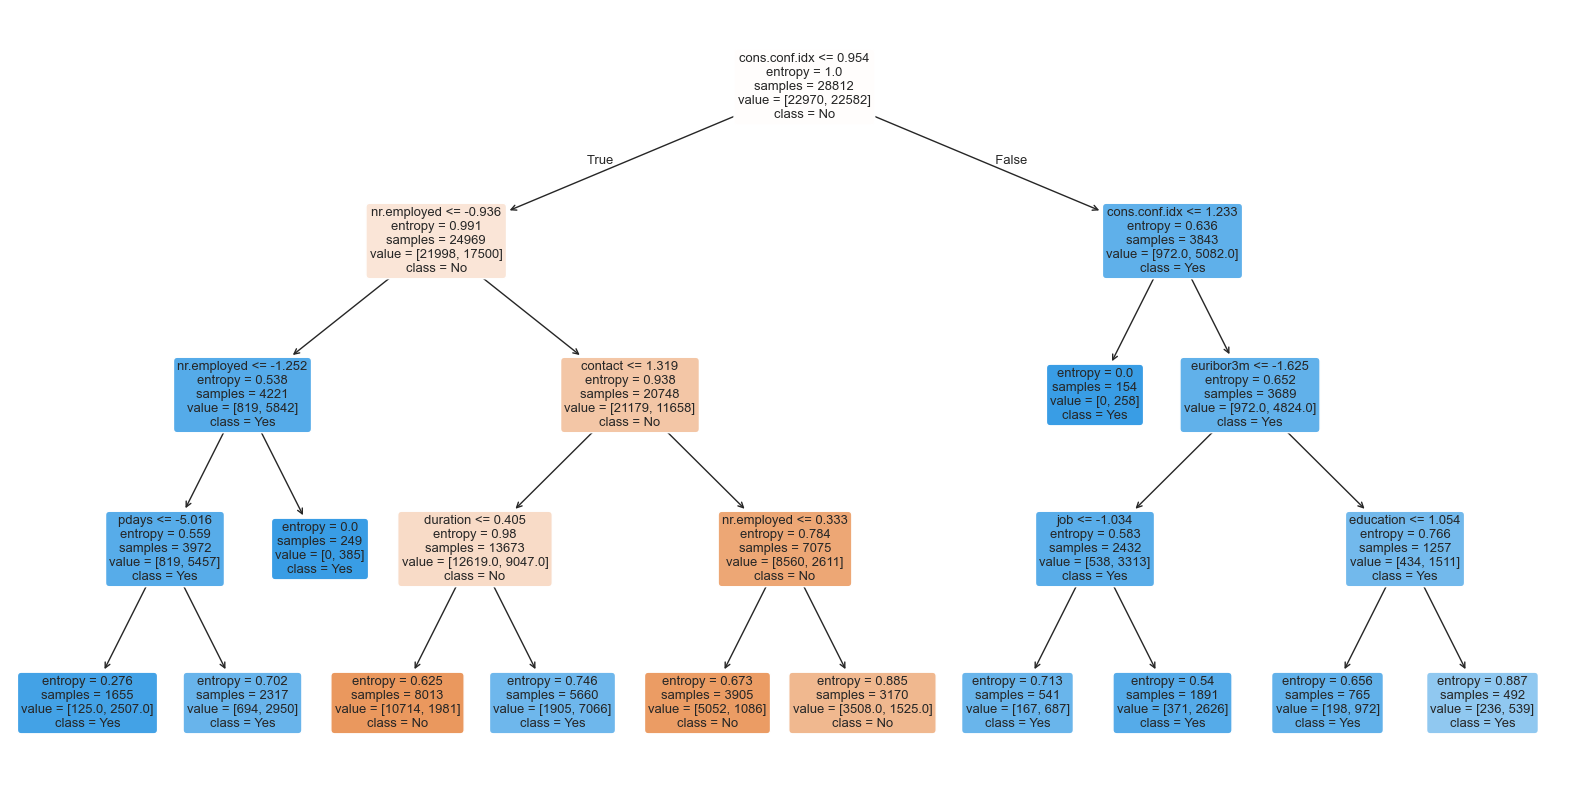

In [ ]:
plt.figure(figsize=(20,10))
plot_tree(final_model.estimators_[0], filled=True, feature_names=train.drop(columns=['y'],axis=1).columns, class_names=['No', 'Yes'], rounded=True)
plt.show()

----------------------------

Jika suatu data dengan variabel `cons.conf.idx` <= 0.954, maka:
  * **TRUE**  : Analisis dilanjutkan ke percabangan kiri
  * **FALSE** : Analisis dilanjutkan ke percabangan kanan

---

Jika kondisi Root Node bernilai **TRUE**
  * Jika variabel `nr.employed` <= -0.936, maka:
    * **TRUE**  : Menuju percabangan kiri
    * **FALSE** : Menuju percabangan kanan

(Percabangan kiri)
  * Jika variabel `nr.employed` <= -1.252, maka:
    * **TRUE**  : Menuju percabangan kiri
      * Jika variabel `pdays` <= -5.016, maka:
        * **TRUE**  : Prediksi = **YES**
        * **FALSE** = Prediksi = **YES**
    * **FALSE** : Prediksi = **YES**


(Percabangan kanan)
  * Jika variabel `contact` <= 1.319, maka:
    * **TRUE**  : Menuju percabangan kiri
      * Jika variabel `duration` <= 0.405, maka:
        * **TRUE**  : Prediksi = **NO**
        * **FALSE** : Prediksi = **NO**
    * **FALSE** : Menuju percabangan kanan
      * Jika variabel `nr.employed` <= 0.333, maka:
       * **TRUE**  : Prediksi = **NO**
       * **FALSE** : Prediksi = **NO**

---

Jika kondisi pada Root Node **FALSE**
  * Jika variabel `cons.conf.idx` <= 1.233
    * **TRUE**  : Prediksi = **YES**
    * **FALSE** : Menuju percabangan kanan

  * Jika variabel `euribor3m` <= -1.625
    * **TRUE**  : Menuju percabangan kiri
      * Jika variabel `job` <= -1.034
        * **TRUE**  : Prediksi = **YES**
        * **FALSE** : Prediksi = **YES**
    * **FALSE** : Menuju percabangan kanan
      * Jika variabel `education` <= 1.054
        * **TRUE**  : Menuju percabangan kiri dan prediksi **YES**
        * **FALSE** : Menuju percabangan kanan dan prediksi **YES**

## Test Processing

In [ ]:
def new_data_process(data):
    col_to_process = ['default', 'housing', 'loan']

    for col in col_to_process:
        if col == 'default':
            data[col].replace('unknown', 'no', inplace=True)
        else:
            data[col].replace('unknown', np.nan, inplace=True)
            data = data[data[col].notna()]

    data['marital'].replace('unknown', np.nan, inplace=True)
    data = data[data['marital'].notna()]

    education_mapping = {
    'primary': ['basic.9y', 'basic.4y', 'basic.6y'],
    'secondary': ['high.school', 'professional.course'],
    'tertiary': ['university.degree'],
    'unknown': ['unknown', 'illiterate']
    }

    educ_flat = {value: key for key, values in education_mapping.items() for value in values}
    data['education'] = data['education'].map(educ_flat)

    return data

Disini kami berusaha untuk mengevaluasi model dengan data yang tidak ikut dilatih (diasumsikan data baru) , preprocessing dilakukan karena untuk melakukan prediksi struktur data baru harus sama seperti yang dijelaskan sebelumnya

In [ ]:
test = new_data_process(test)
test = transform_new_data_le(test, label_encoders1)
test.replace({True: 1, False: 0}, inplace=True)

## Evaluating The Final Model

In [ ]:
y_true = test['y'].values

test = test.drop(columns=['y'], axis=1).values
test = scaler_final.transform(test)

predict = final_model.predict(test)

Setelah di lakukan proses yang sama seperti waktu memroses data uji , kita melakukan prediksi

In [ ]:
print('Classification Report:' )
print(classification_report(y_true, predict))

print('\n')

print('Confusion Matrix:')
print(confusion_matrix(y_true, predict))

print('\n')

print('Accuracy Score:')
print(accuracy_score(y_true, predict))

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.83      0.90      7119
           1       0.41      0.91      0.56       910

    accuracy                           0.84      8029
   macro avg       0.70      0.87      0.73      8029
weighted avg       0.92      0.84      0.86      8029



Confusion Matrix:
[[5926 1193]
 [  86  824]]


Accuracy Score:
0.8407024536056794


Hasil yang diperoleh dengan membandingkan `label` sebenarnya dari data yang ada adalah , model cukup mampu memprediksi dengan baik. Walaupun, akurasi yang diperoleh tidak terlalu bagus namun nilai accuracy sebesar 84% sudah cukup baik. Selain itu , berdasarkan final model yang sudah dilatih dengan (`Accuracy` : 0.832..) , nilai yang diperolah data baru juga masih sedikit mirip dengan hasil latih tersebut. Hal ini mengindikasikan bahwa model yang kita buat sudah cukup baik dan tidak overfit

Confusion Matriks
1. Baris Pertama (untuk '0')
  - 5926 prediksi benar untuk 0.
  - 1193 prediksi salah, di mana model memprediksi "0" sebagai "1"

2. Baris Kedua (untuk '1')
  - 86 prediksi salah, di mana model memprediksi "1" sebagai "0"
  - 824 prediksi benar untuk 1.

### Final Model Feature Importance

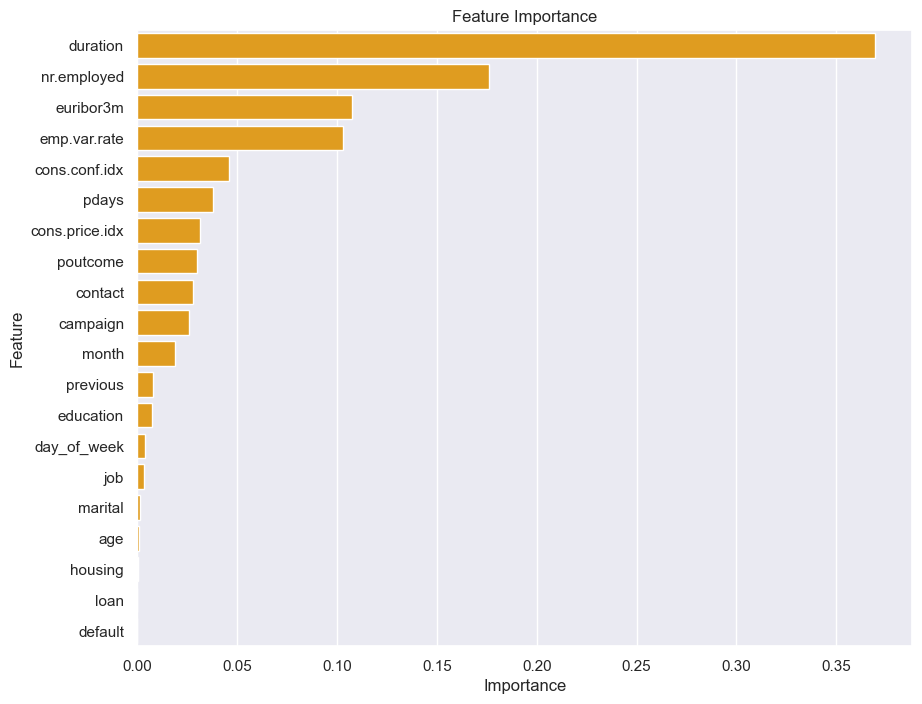

In [ ]:
col_feat = train1.drop(columns=['y'], axis=1).columns

feat_importance = final_model.feature_importances_
feat_importance_df = pd.DataFrame({
    'Feature': col_feat,
    'Importance': feat_importance
})

feat_importance_df = feat_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feat_importance_df,color='orange')
plt.title('Feature Importance')
plt.show()

1. Durasi: Fitur ini menjadi yang paling penting, menunjukkan bahwa durasi kontak terakhir dengan klien sangat prediktif terhadap variabel target.

2. Jumlah karyawan: Jumlah karyawan (indikator ekonomi kuartalan) juga menjadi fitur yang sangat penting.

3. Tingkat Euribor 3 bulan: Tingkat Euribor 3 bulan (indikator ekonomi harian) menjadi fitur ketiga yang paling penting.

4. Tingkat variasi pekerjaan: Tingkat variasi pekerjaan (indikator ekonomi kuartalan) juga merupakan fitur yang penting.

5. Indeks kepercayaan konsumen: Indeks kepercayaan konsumen (indikator ekonomi bulanan) memiliki kepentingan yang moderat.

6. Indeks harga konsumen: Indeks harga konsumen (indikator ekonomi bulanan) juga memiliki kepentingan yang moderat.


# Kesimpulan

Deposito berjangka bank adalah salah satu jenis produk simpanan di bank di mana nasabah menyimpan uang untuk jangka waktu tertentu, misalnya 3 bulan, 6 bulan, atau 1 tahun. Selama uang tersebut disimpan, nasabah akan mendapatkan bunga yang lebih tinggi dibandingkan dengan tabungan biasa.

Jadi dalam konteks ini, kampanye pemasaran yang dilakukan oleh bank di Portugal adalah untuk menawarkan produk deposito berjangka kepada nasabah, dan model machine learning digunakan untuk memprediksi apakah nasabah akan mengambil (berlangganan) produk tersebut atau tidak.

1. Dari data yang ada , data yang dimiliki oleh Bank adalah kebanyakan data kategorik.

2. Pihak bank ingin mampu memprediksi mana pelanggan yang akan melakukan deposito berjangka. Hal ini penting bagi bank karena:

- Jika pelanggan melakukan deposito, itu akan menguntungkan bank, karena bank dapat menggunakan dana tersebut untuk disalurkan kembali sebagai kredit atau pinjaman.

- Sebaliknya, jika pelanggan tidak melakukan deposito, itu tidak akan merugikan bank, tetapi bank juga tidak akan mendapatkan keuntungan dari deposito tersebut.

3. RandomForestClassifier dengan parameter

  - `'n_estimators'`: 150,
  - `'criterion'`: '`entropy'`,
  - `'max_depth'`: 4,
  - `'min_samples_split'`: 4,
  - `'min_samples_leaf'`: 6,
  - `'max_features'`: `'sqrt'`

  adalah model terbaik dan model yang dapat diinterpretasikan dengan baik.



4. Model Mampu menebak / memprediksi pelanggan cukup baik (Akurasi 83%) walaupun dengan nilai yang tidak melebihi 90% hal ini cukup baik karena masih dapat memprediksi keputusan pelanggan untuk Company.

5. Menggunakan model yang dibangun dan menggunakan data baru ternyata mampu memprediksi dengan akurasi yang cukup tinggi, yaitu 84% dari total pelanggan. Ini berarti model tersebut dapat mengidentifikasi dengan benar 84% dari pelanggan, yaitu apakah mereka akan melakukan deposito berjangka atau tidak, dengan membandingkan nilai aktual (y_true) dan nilai prediksi (y_prediksi) dari model akhir.


**Hasil**:

Dengan kemampuan memprediksi mana pelanggan yang akan melakukan deposito, bank dapat lebih fokus untuk menjangkau dan menawarkan produk deposito kepada pelanggan-pelanggan yang diprediksi akan berlangganan.

Hal ini dapat membantu bank meningkatkan pendapatan dan memperbaiki strategi pemasaran mereka.

Jadi inti dari analisis ini adalah untuk meningkatkan kemampuan bank dalam mengidentifikasi dan menjangkau pelanggan yang berpotensi akan melakukan deposito berjangka, sehingga dapat mendorong peningkatan pendapatan bank secara keseluruhan.


**Rekomendasi**:

1. Melakukan Feature Engineering untuk mendapatkan variabel / feature yang lebih merepresentasikan nilai yang ada dan mampu memperoleh variabel yang signfikan

2. Menambah jumlah data latih dan mencoba model ensemble seperti `Bagging Classifier` , `Stacking Classifier` dan `Voting Classifier`